# Quantum Reservoir Computing for compound climate-event early warning
### A *forecast-then-detect* proof of concept — two engines, three real drivers, one honest verdict

This notebook demonstrates a small but complete quantum-reservoir-computing (QRC)
pipeline and, deliberately, tests its central claim to destruction.

**The architecture is forecast-then-detect.** A quantum reservoir is genuinely good
at one thing — turning a time series into a rich bank of temporal features. So we let
it do exactly that (forecasting), and put the rare-event / *compound*-event logic
**downstream** on those features, rather than asking one end-to-end model to also be a
rare-event classifier:

```
   drivers  -►  QUANTUM RESERVOIR  -►  features  -┬-►  ridge  -►  point forecast   (NMSE)
  (SST,SOI,…)   (frozen dynamics)                 └-►  logistic -► P(exceedance)    (detection)
```

**Two engines, validated against each other.**
- `QRC_theoretical.py` — an *exact NumPy statevector* reservoir (the theory).
- `QRC_QPU_implementation.py` — the *Qiskit statevector / shot* twin (the same circuit family).

They are the same physics at the same seed, so the Qiskit port must reproduce the NumPy
features to machine precision. That agreement is the **validation gate** everything rests on.

**The honest thesis.** For extreme and *compound* events the value must be read at the
**end metric** (did we detect the event?), never at forecast NMSE — a forecaster that is
better in the bulk can be worthless in the tail. And the quantum-vs-classical comparison
is reported **either way**, including a clean null.

> All quantum results here are *simulation*. The climate data is **real**.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import data_sources as ds
import pipeline as pl
from QRC_theoretical import (WindowedReservoir, MultiChannelReservoir,
                             run_validation_suite, SEED)
from QRC_QPU_implementation import QiskitReservoir

# One operating point throughout: the reference inner-validation-selected
# (gamma, ent_scale) from the single-variable ENSO study. It is NOT re-tuned
# on any test span or on the compound task (that would be p-hacking).
GAMMA, ENT_SCALE = np.pi / 4, 0.5
L, H = pl.L, pl.HORIZON

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 9, "legend.fontsize": 7.5, "legend.frameon": False,
})
C_TRUTH, C_QRC, C_CLS, C_BAND, C_EVENT = "#333333", "#2166AC", "#D6604D", "#B3CDE3", "#B2182B"
FIG = __import__("pathlib").Path("figures"); FIG.mkdir(exist_ok=True)

print(f"n=5 qubits | gamma=pi/4 | ent_scale={ENT_SCALE} | window L={L} months | "
      f"lead H={H} months | seed={SEED}")

n=5 qubits | gamma=pi/4 | ent_scale=0.5 | window L=24 months | lead H=3 months | seed=7


## 1. The two engines and the validation gate

Before any result counts, the Qiskit statevector twin must reproduce the exact NumPy
reservoir's features. We also confirm the multivariate `MultiChannelReservoir` reduces
*exactly* to the univariate reservoir when given a single channel — so the multivariate
extension is a strict generalisation, not a different model.

In [2]:
run_validation_suite()                      # NumPy anchors (gates, ridge, metrics)

res = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE)
qr  = QiskitReservoir(res=res)
w   = np.random.default_rng(11).uniform(0, 1, L)
gate = np.max(np.abs(qr.exact_features(w) - res.features(w)))
print(f"validation gate   max|qiskit_statevector - numpy_exact|  = {gate:.2e}")

mc1 = MultiChannelReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE, n_channels=1)
red = np.max(np.abs(mc1.features(w.reshape(-1, 1)) - res.features(w)))
print(f"C=1 multichannel  max|MultiChannel(C=1) - Windowed|       = {red:.2e}")
print(f"read-out features per reservoir: {res.n_features()}  (<Z_i>, <X_i>, <Z_iZ_j> at n=5)")

All validation anchors passed.
validation gate   max|qiskit_statevector - numpy_exact|  = 1.78e-15
C=1 multichannel  max|MultiChannel(C=1) - Windowed|       = 0.00e+00
read-out features per reservoir: 20  (<Z_i>, <X_i>, <Z_iZ_j> at n=5)


## 2. The data — three *real*, physically-coupled ENSO drivers

The El Niño–Southern Oscillation is a coupled ocean–atmosphere system, which is exactly
why it is the right testbed for a **compound** event. We pin three real monthly series
(reproducible CSV caches in `data/`, re-derivable with `python data_sources.py --refresh`):

| key | driver | source | role |
|-----|--------|--------|------|
| `sst` | Niño-region sea-surface temperature | NOAA via statsmodels `elnino` | ocean side |
| `soi` | Southern Oscillation Index (Tahiti−Darwin pressure) | NOAA CPC | atmosphere side |
| `pdo` | Pacific Decadal Oscillation index | NOAA PSL | decadal modulation |

Each is deseasonalised into an anomaly against a **train-only** monthly climatology
(no leakage). During an El Niño the ocean warms **and** the Southern Oscillation
collapses (SOI goes strongly negative) *together* — a genuine multi-driver co-exceedance.

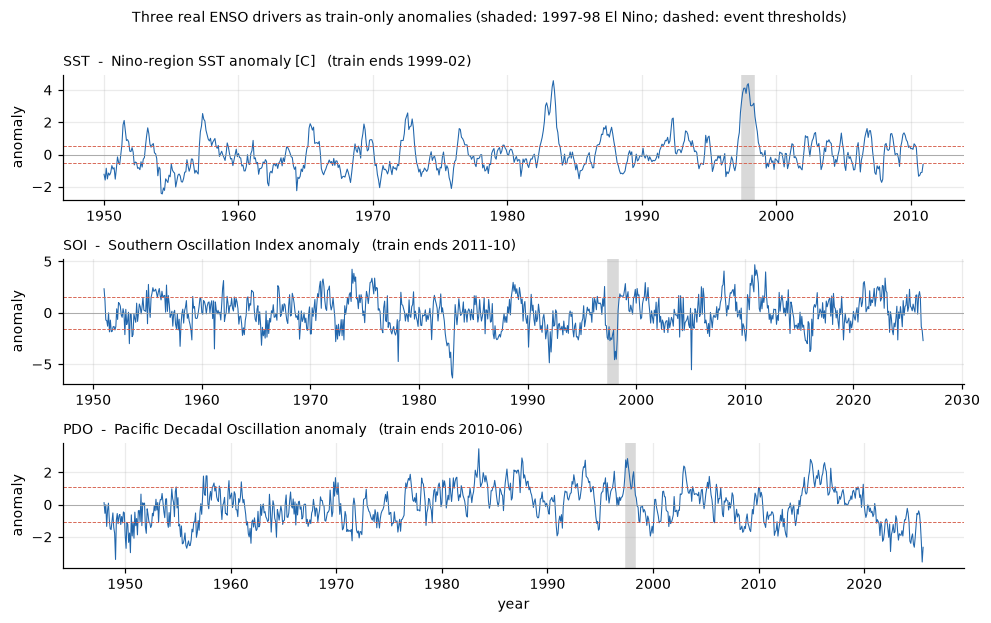

In [3]:
prep = {n: ds.prepare_univariate(n, verbose=False) for n in ds.DATASETS}

fig, axes = plt.subplots(3, 1, figsize=(9.2, 5.6))
for ax, (n, d) in zip(axes, prep.items()):
    t = pd.to_datetime(d["dates"])
    ax.plot(t, d["y"], lw=0.7, color=C_QRC)
    ax.axhline(0, color="0.6", lw=0.5)
    for s in (+1, -1):
        ax.axhline(s * d["event_threshold"], color=C_CLS, lw=0.6, ls="--")
    ax.axvspan(pd.Timestamp("1997-06-01"), pd.Timestamp("1998-05-01"),
               color="0.85", zorder=0)
    ax.set_title(f"{n.upper()}  -  {d['label']}   "
                 f"(train ends {pd.Timestamp(d['dates'][d['n_train']-1]):%Y-%m})",
                 loc="left")
    ax.set_ylabel("anomaly")
axes[-1].set_xlabel("year")
fig.suptitle("Three real ENSO drivers as train-only anomalies "
             "(shaded: 1997-98 El Nino; dashed: event thresholds)", y=1.0, fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "drivers.png", bbox_inches="tight"); plt.show()

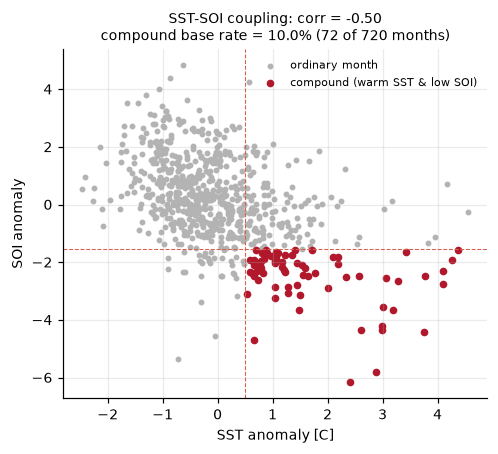

In [4]:
# The coupling that makes a *compound* event meaningful: on the common span,
# warm SST co-occurs with negative SOI. Compound (El Nino) months sit in the
# lower-right quadrant (SST high AND SOI low).
comp2 = ds.prepare_compound(("sst", "soi"), verbose=False)
sst_a, soi_a = comp2["Y"][:, 0], comp2["Y"][:, 1]
r = np.corrcoef(sst_a, soi_a)[0, 1]

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.scatter(sst_a[~comp2["compound"]], soi_a[~comp2["compound"]], s=8,
           color="0.7", label="ordinary month")
ax.scatter(sst_a[comp2["compound"]], soi_a[comp2["compound"]], s=16,
           color=C_EVENT, label="compound (warm SST & low SOI)")
ax.axhline(-comp2["thresholds"][1], color=C_CLS, lw=0.7, ls="--")
ax.axvline(+comp2["thresholds"][0], color=C_CLS, lw=0.7, ls="--")
ax.set(xlabel="SST anomaly [C]", ylabel="SOI anomaly")
ax.set_title(f"SST-SOI coupling: corr = {r:+.2f}\n"
             f"compound base rate = {comp2['compound'].mean():.1%} "
             f"({comp2['compound'].sum()} of {comp2['T']} months)")
ax.legend(loc="upper right")
plt.tight_layout(); plt.savefig(FIG / "coupling.png", bbox_inches="tight"); plt.show()

## 3. Univariate forecast-then-detect — *predicting each dataset*

For every driver we forecast the anomaly **3 months ahead** from the reservoir features
and compare to the classical battery (the bar the QRC must clear):

- `mean` — the train-mean predictor (NMSE = 1 by construction),
- `persistence` — last value carried forward,
- `linear_lags` — ridge on the same 24-month window the QRC sees,
- `esn` — a size-matched classical echo-state network (20 units = 20 features),
- `haar` — the same quantum reservoir but with a *Haar-random* entangler (isolates
  "tuned dynamics" from merely "being quantum").

NMSE is reported both overall and **conditioned on the extreme regime**, where skill
actually matters and decays fastest.

In [5]:
rows, fc_store = [], {}
for n, d in prep.items():
    X = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE).feature_matrix(d["u"], L)
    fc = pl.forecast_univariate(X, d["y"], d["event_threshold"])
    bat = pl.classical_battery(d["y"], d["u"], d["event_threshold"])
    fc_store[n] = (d, fc)
    row = {"dataset": n, "QRC": fc["scores"]["nmse"]}
    row.update({k: v["nmse"] for k, v in bat.items()})
    row["QRC (event-only)"] = fc["scores"]["nmse_event"]
    rows.append(row)

tab = pd.DataFrame(rows).set_index("dataset")
print("3-month-ahead point-forecast NMSE, SINGLE 80/20 split (1.000 = train-mean):")
display(tab.round(3))
print("Audit note (section 8): an earlier version of this battery mis-indexed the ESN --")
print("align() assumes windowed rows, so the ESN was read 23 months STALE -- and fed the")
print("clipped [0,1] series to ESN/linear_lags. Fixed: baselines now consume raw anomalies")
print("with correct indexing (reference parity). The fixed ESN BEATS the QRC on SOI")
print("(0.75 vs 0.81) and PDO (0.47 vs 0.50), and loses narrowly on SST (1.35 vs 1.29).")
print()
print("CAUTION: this is ONE 80/20 split, and for these non-stationary anomalies that is")
print("fragile -- the 80/20 SST test span (1999-2010) is a hard decade, so SST reads 1.29")
print("(apparently worse than the mean). Moving the cut to 70/30 gives ~0.67. The robust,")
print("split-independent number (strict rolling-origin CV) is computed just below.")

3-month-ahead point-forecast NMSE, SINGLE 80/20 split (1.000 = train-mean):


,QRC,mean,persistence,linear_lags,esn,haar,QRC (event-only)
dataset,,,,,,,
sst,1.288,1.0,1.462,1.185,1.345,1.403,1.033
soi,0.806,1.0,1.123,0.792,0.750,0.925,0.647
pdo,0.499,1.0,0.421,0.381,0.468,0.883,0.470


Audit note (section 8): an earlier version of this battery mis-indexed the ESN --
align() assumes windowed rows, so the ESN was read 23 months STALE -- and fed the
clipped [0,1] series to ESN/linear_lags. Fixed: baselines now consume raw anomalies
with correct indexing (reference parity). The fixed ESN BEATS the QRC on SOI
(0.75 vs 0.81) and PDO (0.47 vs 0.50), and loses narrowly on SST (1.35 vs 1.29).

CAUTION: this is ONE 80/20 split, and for these non-stationary anomalies that is
fragile -- the 80/20 SST test span (1999-2010) is a hard decade, so SST reads 1.29
(apparently worse than the mean). Moving the cut to 70/30 gives ~0.67. The robust,
split-independent number (strict rolling-origin CV) is computed just below.


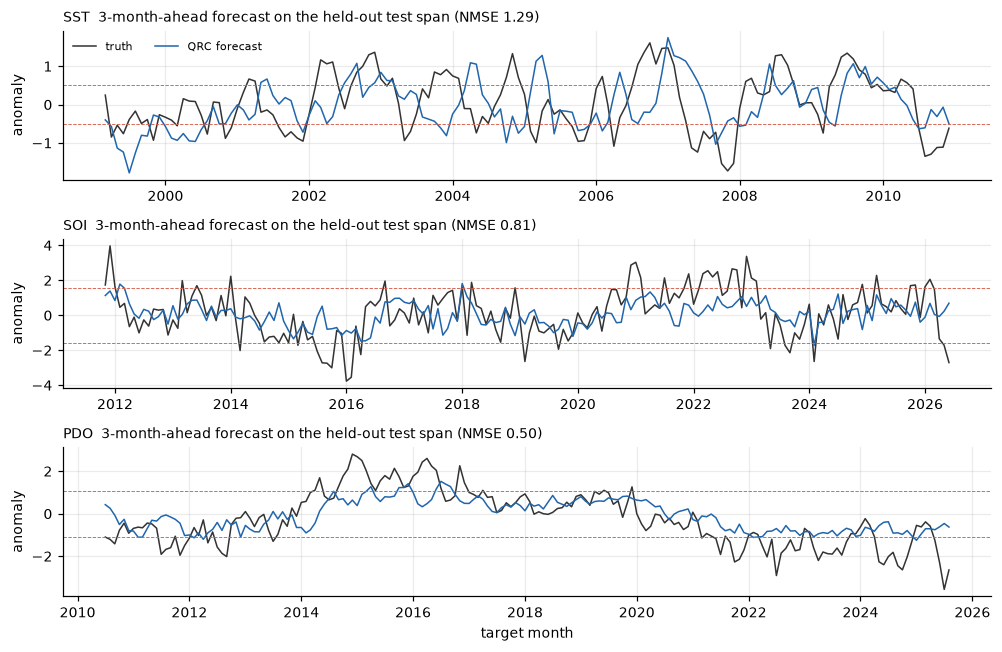

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9.2, 6.0))
for ax, (n, (d, fc)) in zip(axes, fc_store.items()):
    t = pd.to_datetime(d["dates"])[fc["ks"][fc["te"]] + H]
    ax.plot(t, fc["y_test"], color=C_TRUTH, lw=1.0, label="truth")
    ax.plot(t, fc["pred"], color=C_QRC, lw=1.0, label="QRC forecast")
    thr = d["event_threshold"]
    for s in (+1, -1):
        ax.axhline(s * thr, color=C_CLS, lw=0.6, ls="--")
    ax.set_title(f"{n.upper()}  {H}-month-ahead forecast on the held-out test span "
                 f"(NMSE {fc['scores']['nmse']:.2f})", loc="left")
    ax.set_ylabel("anomaly")
    if ax is axes[0]:
        ax.legend(loc="upper left", ncol=2)
axes[-1].set_xlabel("target month")
plt.tight_layout(); plt.savefig(FIG / "forecasts.png", bbox_inches="tight"); plt.show()

**One split is not enough — the robust number.** The table and trajectory above use a single
80/20 chronological split, and for these non-stationary anomalies that is *fragile*: moving the
SST cut from 70/30 to 80/20 swings its `H=3` NMSE from **~0.67 to ~1.29**, purely by where the
test span lands (the 80/20 tail, 1999-2010, is a hard decade). Reporting "SST is worse than the
mean" off that one split would be an **artifact**. So we score the univariate forecast by
**strict rolling-origin cross-validation** — and *strict* matters (audit, section 8): inside each
expanding-window fold **everything** is re-fitted on that fold's train months only — the monthly
climatology, the `[0,1]` encoder scaler, the reservoir feature matrix, and the ridge read-out.
(An earlier version reused the 80%-span climatology/scaler for all folds, quietly leaking each
early test month into its own deseasonalisation — worth ~+0.04 NMSE on SST.)

In [7]:
HZ = [1, 2, 3, 4, 6, 9, 12]        # strict CV computed once per dataset, reused in 3d
cv_strict = {}
cv_rows = []
for n, (d, fc) in fc_store.items():
    month_r, raw_r = ds.raw_series(n)
    res_n = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE)
    cv_strict[n] = pl.forecast_cv_strict(month_r, raw_r,
                                         lambda u: res_n.feature_matrix(u, L),
                                         horizons=tuple(HZ))
    cv = cv_strict[n][H]
    cv_rows.append({"dataset": n, "QRC (strict CV)": cv["qrc"],
                    "persistence (strict CV)": cv["persistence"], "mean": 1.0,
                    "QRC (single-split)": fc["scores"]["nmse"],
                    "pooled test N": cv["n"]})
print(f"STRICT rolling-origin CV {H}-month forecast NMSE (per-fold transforms; 1.0 = mean):")
display(pd.DataFrame(cv_rows).set_index("dataset").round(3))
print("Reading it honestly (robust and leak-free):")
print(" - Under strict CV the QRC beats the train-MEAN on all three at H=3")
print("   (0.70 / 0.82 / 0.62 < 1): the single-split 'SST worse than the mean' was a split")
print("   artifact, not a property of the reservoir -- it extracts a real signal.")
print(" - What it still does NOT do is beat trivial PERSISTENCE at H=3, except on SOI")
print("   (0.82 < 0.92); on SST (0.70 vs 0.58) and PDO (0.62 vs 0.52) persistence stays")
print("   ahead, and the fixed classical battery (ESN, linear lags) is comparable or better.")
print("   Genuine skill over the mean, no edge over classical baselines -- the value question")
print("   stays DOWNSTREAM at compound detection, not at forecast NMSE.")

STRICT rolling-origin CV 3-month forecast NMSE (per-fold transforms; 1.0 = mean):


,QRC (strict CV),persistence (strict CV),mean,QRC (single-split),pooled test N
dataset,,,,,
sst,0.696,0.584,1.0,1.288,440
soi,0.817,0.924,1.0,0.806,544
pdo,0.619,0.520,1.0,0.499,560


Reading it honestly (robust and leak-free):
 - Under strict CV the QRC beats the train-MEAN on all three at H=3
   (0.70 / 0.82 / 0.62 < 1): the single-split 'SST worse than the mean' was a split
   artifact, not a property of the reservoir -- it extracts a real signal.
 - What it still does NOT do is beat trivial PERSISTENCE at H=3, except on SOI
   (0.82 < 0.92); on SST (0.70 vs 0.58) and PDO (0.62 vs 0.52) persistence stays
   ahead, and the fixed classical battery (ESN, linear lags) is comparable or better.
   Genuine skill over the mean, no edge over classical baselines -- the value question
   stays DOWNSTREAM at compound detection, not at forecast NMSE.


### 3a. The same forecast on the **Qiskit statevector** engine

The flagship SST forecast, recomputed with the Qiskit statevector twin instead of NumPy.
Because the two engines are validated equal, the forecasts must coincide — this is the
"quantum simulator actually predicts the data" demonstration.

In [8]:
d = prep["sst"]
res_u = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE)
Xn = res_u.feature_matrix(d["u"], L)                       # NumPy engine
Xq = QiskitReservoir(res=res_u).exact_feature_matrix(d["u"], L)  # Qiskit statevector
fcn = pl.forecast_univariate(Xn, d["y"], d["event_threshold"])
fcq = pl.forecast_univariate(Xq, d["y"], d["event_threshold"])
print(f"SST {H}-month NMSE   NumPy engine       = {fcn['scores']['nmse']:.6f}")
print(f"SST {H}-month NMSE   Qiskit statevector = {fcq['scores']['nmse']:.6f}")
print(f"max |NumPy forecast - Qiskit forecast| on the test span = "
      f"{np.max(np.abs(fcn['pred'] - fcq['pred'])):.2e}   (two engines, one answer)")

SST 3-month NMSE   NumPy engine       = 1.287856
SST 3-month NMSE   Qiskit statevector = 1.287856
max |NumPy forecast - Qiskit forecast| on the test span = 7.55e-15   (two engines, one answer)


### 3b. The *detect* stage on each driver

Downstream of the forecast we train a **logistic exceedance head** that emits
`P(warm/high extreme at k+H)` directly — the right objective for a rare event. We score
it threshold-free with **average precision** (AP, the area under the precision-recall
curve, the honest metric for imbalanced events) and ROC-AUC. The operating point for
F1 is chosen on an inner-validation slice of the train span only.

In [9]:
rows = []
for n, d in prep.items():
    X = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE).feature_matrix(d["u"], L)
    s = pl.make_samples(len(d["y"]))
    labels = (d["y"] > d["event_threshold"]).astype(int)      # one-sided warm/high extreme
    h = pl.exceedance_head(X, labels, s)
    rows.append({"dataset": n, "event base rate": h["base_rate"], "AP": h["ap"],
                 "ROC-AUC": h["auc"], "precision": h["precision"],
                 "recall": h["recall"], "F1": h["f1"]})
print(f"Univariate extreme-event detection at H={H} months (one-sided warm/high tail):")
display(pd.DataFrame(rows).set_index("dataset").round(3))

Univariate extreme-event detection at H=3 months (one-sided warm/high tail):


,event base rate,AP,ROC-AUC,precision,recall,F1
dataset,,,,,,
sst,0.296,0.397,0.608,0.361,0.524,0.427
soi,0.170,0.370,0.756,0.193,0.967,0.322
pdo,0.165,0.578,0.875,0.484,0.500,0.492


### 3c. Theoretical (exact) vs sampling (finite-shot) forecasts

Everything so far used the reservoir's **exact** features — the `S -> inf` statevector
expectation values. On real hardware each `<Z_i>`, `<X_i>`, `<Z_iZ_j>` is estimated from a
finite number of measurement shots `S`, injecting binomial sampling noise (`~ S^{-1/2}`). We
now forecast each driver with exact vs finite-shot features — the read-out is fit on the same
sampled features it predicts from, the honest device pipeline — and ask *how many shots buy
back the theoretical forecast*. First: the finite-shot emulator we use is the **same**
sampling process as the Qiskit AerSimulator path (both are unbiased estimators of the exact
features), so this ties the two engines together once more.

In [10]:
from QRC_QPU_implementation import get_backend

_res = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE)
_w0 = prep["sst"]["u"][:L]
_exact0 = _res.features(_w0)
# numpy finite-shot emulator: mean over many draws -> the exact features (unbiased)
_np_mean = np.mean([_res.sampled_features(_w0, 4096, np.random.default_rng(i))
                    for i in range(200)], axis=0)
# one Qiskit AerSimulator (noiseless) sampled draw at S=4096
_qk0 = QiskitReservoir(res=_res).sampled_feature_matrix(
    _w0, L, shots=4096, backend=get_backend("aer", noise=False), verbose=False)[0]
print(f"max|numpy-sampled mean (S=4096, 200 draws) - exact| = {np.max(np.abs(_np_mean - _exact0)):.3f}")
print(f"max|Qiskit-Aer-sampled (S=4096, 1 draw)     - exact| = {np.max(np.abs(_qk0 - _exact0)):.3f}")
print("=> both sampling paths are unbiased estimators of the exact features; the per-draw")
print("   scatter (single Aer draw) is exactly the shot noise the forecast below must absorb.")

backend: AerSimulator noise=off seed=7


max|numpy-sampled mean (S=4096, 200 draws) - exact| = 0.002
max|Qiskit-Aer-sampled (S=4096, 1 draw)     - exact| = 0.029
=> both sampling paths are unbiased estimators of the exact features; the per-draw
   scatter (single Aer draw) is exactly the shot noise the forecast below must absorb.


In [11]:
SHOTS_OVERLAY = [1024, 128]                       # budgets drawn on the trajectory
SHOT_GRID     = [16, 32, 64, 128, 256, 1024, 4096]
N_SEEDS       = 5
C_SHOTS = {1024: "#2ca02c", 128: "#d62728"}       # green = many shots, red = few

samp = {}
for n, d in prep.items():
    res = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE)
    cache = pl.probs_cache(res, d["u"])
    fc_exact = pl.forecast_univariate(res.feature_matrix(d["u"], L),
                                      d["y"], d["event_threshold"])
    fc_S = {S: pl.forecast_univariate(
                pl.sampled_feature_matrix(res, d["u"], S, 7, cache=cache),
                d["y"], d["event_threshold"]) for S in SHOTS_OVERLAY}
    samp[n] = dict(d=d, res=res, cache=cache, exact=fc_exact, sampled=fc_S)
    row = "  ".join(f"S={S}: {fc_S[S]['scores']['nmse']:.3f}" for S in SHOTS_OVERLAY)
    print(f"{n:4s} exact NMSE={fc_exact['scores']['nmse']:.3f}   {row}")

sst  exact NMSE=1.288   S=1024: 1.314  S=128: 1.232


soi  exact NMSE=0.806   S=1024: 0.798  S=128: 0.893


pdo  exact NMSE=0.499   S=1024: 0.513  S=128: 0.541


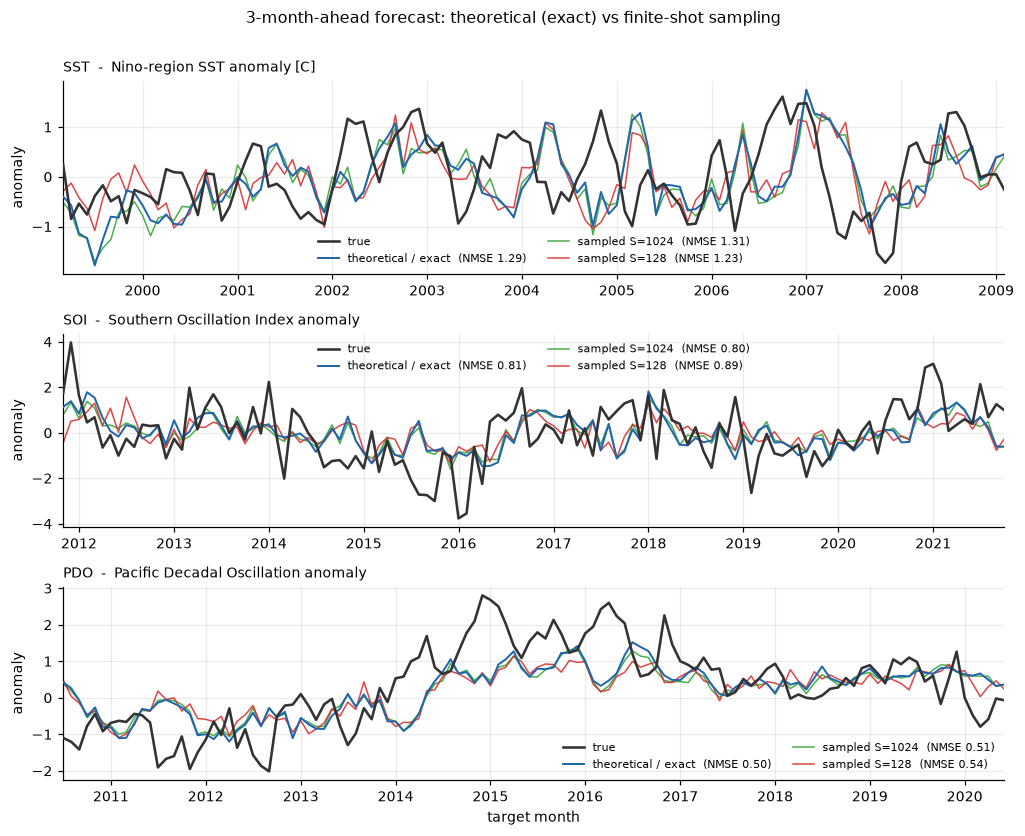

In [12]:
fig, axes = plt.subplots(len(prep), 1, figsize=(9.4, 2.5 * len(prep)))
axes = np.atleast_1d(axes)
for ax, n in zip(axes, prep):
    R = samp[n]; d = R["d"]; ex = R["exact"]
    t = pd.to_datetime(d["dates"])[ex["ks"][ex["te"]] + H]
    z = slice(0, min(120, len(t)))
    ax.plot(t[z], ex["y_test"][z], color=C_TRUTH, lw=1.7, label="true", zorder=5)
    ax.plot(t[z], ex["pred"][z], color=C_QRC, lw=1.3,
            label=f"theoretical / exact  (NMSE {ex['scores']['nmse']:.2f})", zorder=4)
    for S in SHOTS_OVERLAY:
        rp = R["sampled"][S]
        ax.plot(t[z], rp["pred"][z], color=C_SHOTS[S], lw=1.0, alpha=0.85,
                label=f"sampled S={S}  (NMSE {rp['scores']['nmse']:.2f})")
    ax.set_title(f"{n.upper()}  -  {d['label']}", loc="left")
    ax.set_ylabel("anomaly"); ax.legend(fontsize=7, ncol=2, loc="best"); ax.margins(x=0)
axes[-1].set_xlabel("target month")
fig.suptitle(f"{H}-month-ahead forecast: theoretical (exact) vs finite-shot sampling",
             y=1.005, fontsize=10.5)
plt.tight_layout(); plt.savefig(FIG / "sampling_trajectory.png", bbox_inches="tight"); plt.show()

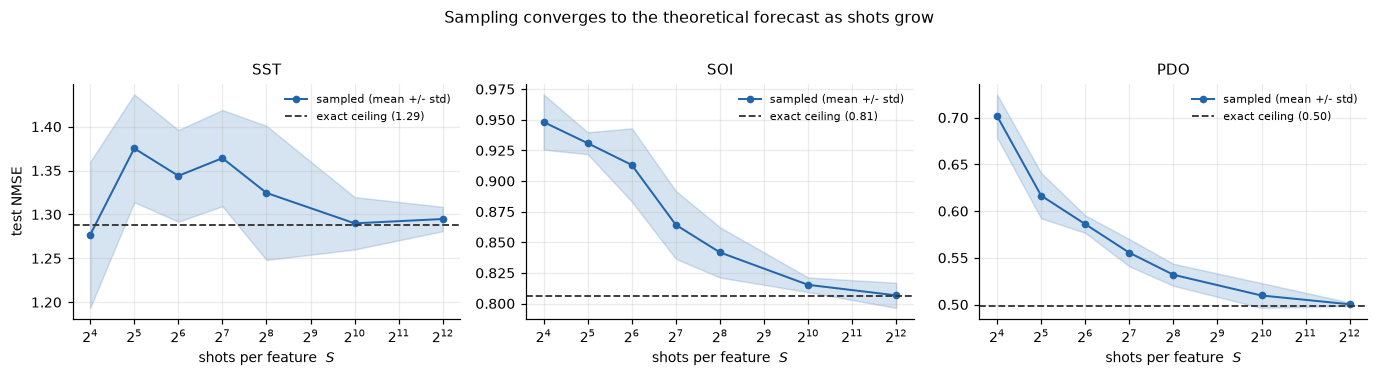

In [13]:
fig, axes = plt.subplots(1, len(prep), figsize=(4.2 * len(prep), 3.3))
axes = np.atleast_1d(axes)
for ax, n in zip(axes, prep):
    R = samp[n]; d = R["d"]
    mean, std, exact = pl.forecast_nmse_vs_shots(
        R["res"], d["y"], d["u"], d["event_threshold"], SHOT_GRID,
        n_seeds=N_SEEDS, cache=R["cache"])
    ax.fill_between(SHOT_GRID, mean - std, mean + std, color=C_QRC, alpha=0.18)
    ax.plot(SHOT_GRID, mean, "o-", color=C_QRC, lw=1.3, ms=4, label="sampled (mean +/- std)")
    ax.axhline(exact, color=C_TRUTH, ls="--", lw=1.2, label=f"exact ceiling ({exact:.2f})")
    ax.set_xscale("log", base=2); ax.set_xlabel("shots per feature  $S$")
    ax.set_title(n.upper(), fontsize=9.5)
    if ax is axes[0]:
        ax.set_ylabel("test NMSE")
    ax.legend(fontsize=7.3, loc="upper right")
fig.suptitle("Sampling converges to the theoretical forecast as shots grow", y=1.02, fontsize=10.5)
plt.tight_layout(); plt.savefig(FIG / "sampling_nmse_vs_shots.png", bbox_inches="tight"); plt.show()

**Reading it honestly.** As `S -> ∞` every sampled forecast converges to its exact ceiling —
that convergence is the point. But the *approach* is not uniform. For the well-conditioned
drivers (PDO, and largely SOI) sampling degrades the forecast and closes the gap from **above**
at the `S^{-1/2}` rate — more shots, less scatter, closer to the theoretical curve. For **SST**
it is **non-monotonic**: the exact forecast is already worse than the train-mean (NMSE > 1, an
over-fit read-out), so shot noise acts as mild **regularisation** and the sampled NMSE can sit
at or even *below* the exact ceiling at low `S` before settling back to it. Note too that the
lower-NMSE, better-forecast drivers are the most *shot-hungry* — a fixed additive shot-noise
floor is a larger fraction of a small NMSE. The read-out is fit on the sampled features it
predicts from (honest end-to-end device numbers, not a train-on-exact cheat); a real device
shares one shot budget across commuting observables, so the effective cost is lower than a
naive per-feature `S` reading suggests.

### 3d. Step-by-step (1-month) forecasting — and why the headline uses a 3-month lead

Everything above forecasts **3 months ahead** (`H = 3`). That was deliberate — here is the
honest why, next to the step-by-step (`H = 1`) forecast the question asks for.

**Why `H = 3`.** Two reasons, one about the product and one about the method.
1. *Decision relevance.* The deliverable is compound-event **early warning**, and a warning is
   only worth anything with enough **lead time to act** (inspect, protect product, issue an
   advisory). A one-step (one-month) forecast of a slowly-varying climate anomaly gives almost
   no warning; three months is the standard operational ENSO lead and a genuinely actionable one.
2. *It is the honest, harder test.* At `H = 1` the series barely moves month to month, so
   trivial **persistence** (next month ~ this month) is a brutal baseline — often unbeatable.
   A short horizon therefore flatters *persistence*, not the reservoir, and hides whether the
   learned temporal features add anything. Skill only separates the models at longer leads.

The step-by-step forecast and the skill-vs-lead curve below make both points concrete.

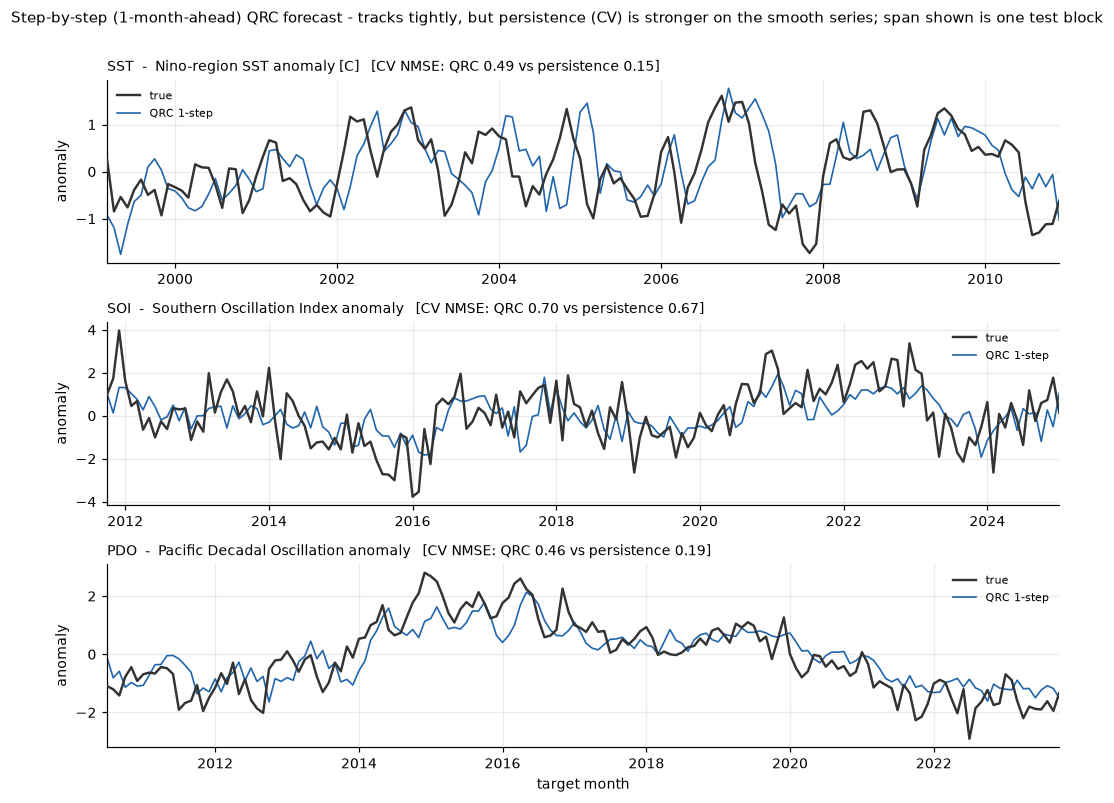

In [14]:
H1 = 1
fig, axes = plt.subplots(len(prep), 1, figsize=(9.4, 2.4 * len(prep)))
axes = np.atleast_1d(axes)
for ax, n in zip(axes, prep):
    d = prep[n]
    res = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE)
    Xall = res.feature_matrix(d["u"], L)
    s1 = pl.make_samples(len(d["y"]), H=H1)
    ks, tr, te = s1["ks"], s1["tr"], s1["te"]
    fc1 = pl.forecast_univariate(Xall, d["y"], d["event_threshold"], samples=s1)
    cv1 = cv_strict[n][H1]                    # strict per-fold CV (section 3)
    t = pd.to_datetime(d["dates"])[ks[te] + H1]
    z = slice(0, min(160, len(t)))
    ax.plot(t[z], fc1["y_test"][z], color=C_TRUTH, lw=1.6, label="true", zorder=5)
    ax.plot(t[z], fc1["pred"][z], color=C_QRC, lw=1.1, label="QRC 1-step")
    ax.set_title(f"{n.upper()}  -  {d['label']}   "
                 f"[CV NMSE: QRC {cv1['qrc']:.2f} vs persistence {cv1['persistence']:.2f}]",
                 loc="left", fontsize=9)
    ax.set_ylabel("anomaly"); ax.legend(fontsize=7.5, loc="best"); ax.margins(x=0)
axes[-1].set_xlabel("target month")
fig.suptitle("Step-by-step (1-month-ahead) QRC forecast - tracks tightly, but persistence "
             "(CV) is stronger on the smooth series; span shown is one test block", y=1.005, fontsize=10)
plt.tight_layout(); plt.savefig(FIG / "forecast_1step.png", bbox_inches="tight"); plt.show()

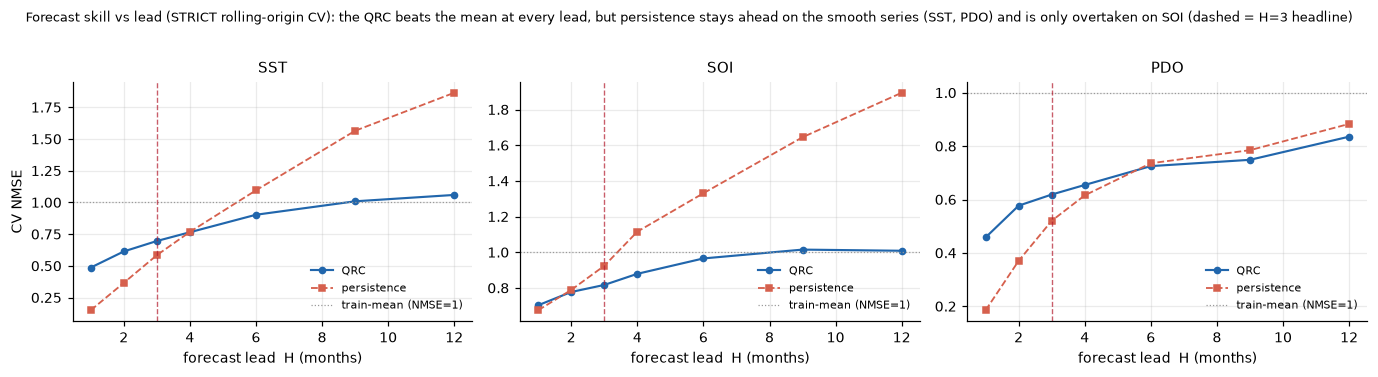

Strict rolling-origin CV NMSE at H=1 (step-by-step) vs H=3 (headline):


,QRC H=1,persist H=1,QRC H=3,persist H=3
dataset,,,,
sst,0.487,0.150,0.696,0.584
soi,0.703,0.675,0.817,0.924
pdo,0.458,0.185,0.619,0.520


In [15]:
fig, axes = plt.subplots(1, len(prep), figsize=(4.2 * len(prep), 3.3))
axes = np.atleast_1d(axes)
rows = []
for ax, n in zip(axes, prep):
    cur = dict(qrc=np.array([cv_strict[n][h]["qrc"] for h in HZ]),   # strict CV, section 3
               persistence=np.array([cv_strict[n][h]["persistence"] for h in HZ]))
    ax.plot(HZ, cur["qrc"], "o-", color=C_QRC, lw=1.4, ms=4, label="QRC")
    ax.plot(HZ, cur["persistence"], "s--", color=C_CLS, lw=1.2, ms=4, label="persistence")
    ax.axhline(1.0, color="0.6", lw=0.8, ls=":", label="train-mean (NMSE=1)")
    ax.axvline(3, color=C_EVENT, lw=0.9, ls="--", alpha=0.7)
    ax.set_xlabel("forecast lead  H (months)"); ax.set_title(n.upper(), fontsize=9.5)
    if ax is axes[0]:
        ax.set_ylabel("CV NMSE")
    ax.legend(fontsize=7.2, loc="best")
    i1, i3 = HZ.index(1), HZ.index(3)
    rows.append({"dataset": n, "QRC H=1": cur["qrc"][i1], "persist H=1": cur["persistence"][i1],
                 "QRC H=3": cur["qrc"][i3], "persist H=3": cur["persistence"][i3]})
fig.suptitle("Forecast skill vs lead (STRICT rolling-origin CV): the QRC beats the mean at "
             "every lead, but persistence stays ahead on the smooth series (SST, PDO) and is "
             "only overtaken on SOI (dashed = H=3 headline)", y=1.02, fontsize=8.5)
plt.tight_layout(); plt.savefig(FIG / "nmse_vs_horizon.png", bbox_inches="tight"); plt.show()
print("Strict rolling-origin CV NMSE at H=1 (step-by-step) vs H=3 (headline):")
display(pd.DataFrame(rows).set_index("dataset").round(3))

**What the step-by-step view shows (honestly, under CV).**

- **Short leads are a persistence game.** At `H = 1`, trivially copying `y_k` is a fierce
  baseline on these smooth anomalies — under strict CV persistence *beats* the QRC on SST (0.15
  vs 0.49) and PDO (0.19 vs 0.46), and edges it on SOI (0.68 vs 0.70). A one-step forecast says
  more about the series' autocorrelation than about the reservoir.
- **Skill separates as the lead grows — but modestly.** Persistence error climbs with `H`
  (it inherits the series' `H`-step variability) while the QRC degrades more gently, so the gap
  narrows. On **SOI** the curves genuinely **cross** (the QRC overtakes persistence by `H = 3`);
  on the smoother, more autocorrelated **SST and PDO** persistence stays ahead even at `H = 3`.
  So a learned model does not universally beat the trivial baseline here — the honest claim is
  narrower: it beats the *mean* at every lead, and beats *persistence* only where the series is
  less persistent.
- **Why `H = 3` then?** Mostly **decision relevance**: three months is the shortest ENSO lead
  that is operationally actionable, and it is where the QRC is at least competitive with
  persistence rather than dominated by it. `H = 1` is a fine sanity check — the reservoir does
  forecast, and tracks tightly — but it measures persistence, not the reservoir.

## 4. The compound event — where a *multivariate* reservoir should earn its keep

A **compound El Nino** month is defined as *warm ocean AND collapsed Southern Oscillation
at the same target month*: `SST anomaly > +thr` **and** `SOI anomaly < -thr`. This is a
genuine co-exceedance with tail dependence — not two independent alarms — and univariate
analysis systematically under-estimates its risk because it ignores the dependence.

We now test the falsifiable claim head-on:

> *A **joint** multichannel reservoir captures inter-driver dependence that improves
> compound-event detection over both a **bank** of one-channel reservoirs and a classical
> multivariate **ESN** — read at the compound-detection metric.*

Three feature sources feed the **same** exceedance head on the **same** compound labels:
`joint` (one `MultiChannelReservoir`, cross-channel quantum features) · `bank` (one
`WindowedReservoir` per driver, concatenated — per-channel only) · `esn_multi`
(size-matched classical multivariate ESN).

In [16]:
comp = ds.prepare_compound(("sst", "soi"), verbose=True)
exp = pl.compound_experiment(comp, gamma=GAMMA, ent_scale=ENT_SCALE, seed=SEED)

print("\n--- Failure mode 1: a POINT forecast damps the very events you want ---")
print(f"naive  point-forecast-then-threshold : recall={exp['naive']['recall']:.2f}  "
      f"F1={exp['naive']['f1']:.2f}   (mean-regression under-shoots the tail)")
print(f"proper probabilistic exceedance head : recall={exp['heads']['joint']['recall']:.2f}  "
      f"F1={exp['heads']['joint']['f1']:.2f}   (optimises the rare-event objective)")

[compound sst+soi] 720 months 1951-01..2010-12; train [0,581); compound base rate 0.100 (72 months)



--- Failure mode 1: a POINT forecast damps the very events you want ---
naive  point-forecast-then-threshold : recall=0.00  F1=0.00   (mean-regression under-shoots the tail)
proper probabilistic exceedance head : recall=0.67  F1=0.17   (optimises the rare-event objective)


**Failure mode 1, confirmed.** Thresholding a point forecast regresses to the mean and
misses the compound tail almost entirely. Emitting an exceedance *probability* directly
is the architecturally correct fix. Now the head-to-head, made robust with **rolling-origin
cross-validation** — out-of-sample probabilities pooled across expanding-window folds so
AP/AUC use *every* compound event in the record, not the handful in a single test tail.

Compound SST+SOI detection, rolling-origin CV (52 events / 417 months, base 12.5%):


,avg precision,ROC-AUC,mean F1
joint (QRC),0.324,0.694,0.204
bank (QRC),0.357,0.731,0.258
ESN (classical),0.418,0.826,0.312


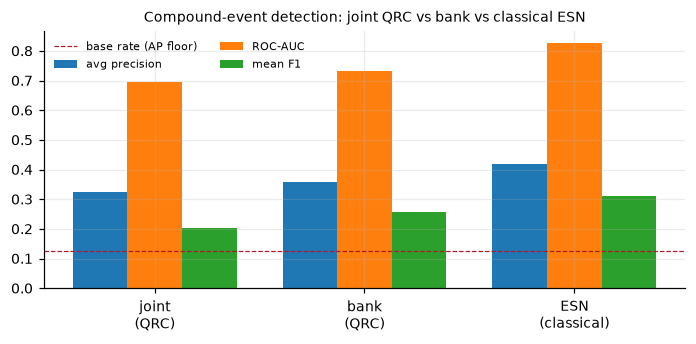

In [17]:
cv = pl.compound_cv(comp, gamma=GAMMA, ent_scale=ENT_SCALE, seed=SEED)
tab = pd.DataFrame({
    m: {k: cv[k][m] for k in cv} for m in ("ap", "auc", "f1_mean")
}).rename(columns={"ap": "avg precision", "auc": "ROC-AUC", "f1_mean": "mean F1"})
tab.index = ["joint (QRC)", "bank (QRC)", "ESN (classical)"]
print(f"Compound SST+SOI detection, rolling-origin CV "
      f"({cv['joint']['n_event']} events / {cv['joint']['n']} months, "
      f"base {cv['joint']['base_rate']:.1%}):")
display(tab.round(3))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
x = np.arange(3); wbar = 0.26
for i, m in enumerate(("ap", "auc", "f1_mean")):
    ax.bar(x + (i - 1) * wbar, [cv["joint"][m], cv["bank"][m], cv["esn_multi"][m]],
           wbar, label={"ap": "avg precision", "auc": "ROC-AUC", "f1_mean": "mean F1"}[m])
ax.axhline(cv["joint"]["base_rate"], color=C_EVENT, ls="--", lw=0.8,
           label="base rate (AP floor)")
ax.set_xticks(x); ax.set_xticklabels(["joint\n(QRC)", "bank\n(QRC)", "ESN\n(classical)"])
ax.set_title("Compound-event detection: joint QRC vs bank vs classical ESN")
ax.legend(ncol=2, loc="upper left")
plt.tight_layout(); plt.savefig(FIG / "compound_bars.png", bbox_inches="tight"); plt.show()

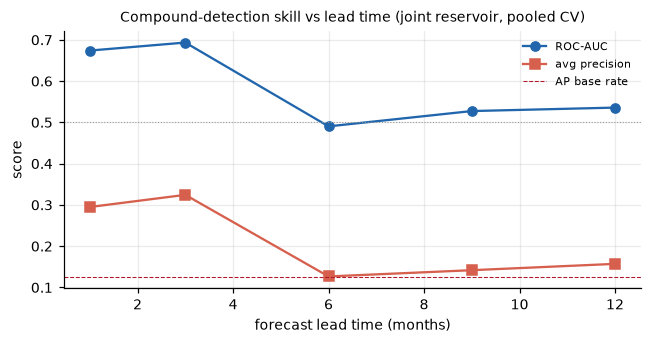

AUC by lead: {1: 0.67, 3: 0.69, 6: 0.49, 9: 0.53, 12: 0.54}


In [18]:
# Failure mode 2: tail skill decays with lead time faster than bulk skill.
sh = pl.skill_vs_horizon(comp, horizons=(1, 3, 6, 9, 12), gamma=GAMMA,
                         ent_scale=ENT_SCALE, seed=SEED)
Hs = list(sh)
fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.plot(Hs, [sh[h]["auc"] for h in Hs], "o-", color=C_QRC, label="ROC-AUC")
ax.plot(Hs, [sh[h]["ap"] for h in Hs], "s-", color=C_CLS, label="avg precision")
ax.axhline(0.5, color="0.6", lw=0.7, ls=":")
ax.axhline(sh[Hs[0]]["base_rate"], color=C_EVENT, lw=0.7, ls="--", label="AP base rate")
ax.set(xlabel="forecast lead time (months)", ylabel="score",
       title="Compound-detection skill vs lead time (joint reservoir, pooled CV)")
ax.legend(loc="upper right")
plt.tight_layout(); plt.savefig(FIG / "skill_horizon.png", bbox_inches="tight"); plt.show()
print("AUC by lead:", {h: round(sh[h]["auc"], 2) for h in Hs})

In [19]:
# The rarer three-driver compound (adds PDO): warm SST AND low SOI AND warm PDO.
comp3 = ds.prepare_compound(("sst", "soi", "pdo"), verbose=True)
cv3 = pl.compound_cv(comp3, gamma=GAMMA, ent_scale=ENT_SCALE, seed=SEED)
tab3 = pd.DataFrame({m: {k: cv3[k][m] for k in cv3} for m in ("ap", "auc", "f1_mean")}
                    ).rename(columns={"ap": "avg precision", "auc": "ROC-AUC", "f1_mean": "mean F1"})
tab3.index = ["joint (QRC)", "bank (QRC)", "ESN (classical)"]
print(f"\nCompound SST+SOI+PDO (rarer: {cv3['joint']['n_event']} events, "
      f"base {cv3['joint']['base_rate']:.1%}):")
display(tab3.round(3))

[compound sst+soi+pdo] 720 months 1951-01..2010-12; train [0,581); compound base rate 0.039 (28 months)



Compound SST+SOI+PDO (rarer: 27 events, base 6.5%):


,avg precision,ROC-AUC,mean F1
joint (QRC),0.127,0.497,0.105
bank (QRC),0.282,0.613,0.130
ESN (classical),0.122,0.644,0.111


## 5. Giving the joint reservoir a *fair* operating point — and a look from the matrices

The null above used one fixed operating point (`gamma=pi/4, s=0.5`), inherited from the
univariate study and never tuned for the multichannel encoding — a genuine confound. So we
now **sweep the joint reservoir's `gamma` and `ent_scale`** on the compound task (on the exact
matrix reservoir), give the classical `bank` the same tuning freedom, and ask: *does a fair
operating point overturn the null?*

Alongside it we add a **theoretical panel computed directly from the reservoir matrices** —
no task data, no fitted detector:

- **memory capacity** `MC(gamma, s)` — how much of the recent multi-channel input history the
  20-D feature map linearly retains, from the reservoir's own feature statistics on i.i.d.
  input (`QRC_theoretical.linear_memory_capacity`);
- **entangler scrambling** — the circular variance of the frozen entangler `W`'s eigenphases
  (`1 - |mean e^{iphi}|`), *pure linear algebra on the matrix* (`entangler_scrambling`).

Reading the grid **max** is deliberately optimistic (the cell is chosen on the same CV): if
the joint reservoir cannot beat the classical alternatives even at its best cell, the null
is robust.

In [20]:
GAMMAS = [np.pi / 8, np.pi / 4, np.pi / 2, np.pi]
ENTS   = [0.25, 0.5, 1.0, 1.5]
GLAB   = [r"$\pi/8$", r"$\pi/4$", r"$\pi/2$", r"$\pi$"]

sweep_joint = pl.operating_sweep(comp, GAMMAS, ENTS, model="joint", seed=SEED)
sweep_bank  = pl.operating_sweep(comp, GAMMAS, ENTS, model="bank",  seed=SEED)
mcgrid      = pl.memory_capacity_grid(comp, GAMMAS, ENTS, seed=SEED, T=900)
esn_ref     = pl.compound_cv(comp, gamma=GAMMA, ent_scale=ENT_SCALE, seed=SEED)["esn_multi"]

print(f"reference joint (pi/4, 0.5)   AP={sweep_joint['ap'][1, 1]:.3f}")
print(f"BEST joint over grid          AP={sweep_joint['best']['ap']:.3f}  "
      f"(gamma={sweep_joint['best']['gamma']:.3f}, s={sweep_joint['best']['ent_scale']}, "
      f"AUC={sweep_joint['best']['auc']:.3f})")
print(f"BEST bank  over grid          AP={sweep_bank['best']['ap']:.3f}  "
      f"(gamma={sweep_bank['best']['gamma']:.3f}, s={sweep_bank['best']['ent_scale']}, "
      f"AUC={sweep_bank['best']['auc']:.3f})")
print(f"classical ESN (fixed)         AP={esn_ref['ap']:.3f}   AUC={esn_ref['auc']:.3f}")
print(f"entangler scrambling vs s={ENTS}: {np.round(mcgrid['scrambling'], 3)}")

reference joint (pi/4, 0.5)   AP=0.324
BEST joint over grid          AP=0.406  (gamma=0.785, s=1.5, AUC=0.706)
BEST bank  over grid          AP=0.442  (gamma=0.393, s=1.0, AUC=0.767)
classical ESN (fixed)         AP=0.418   AUC=0.826
entangler scrambling vs s=[0.25, 0.5, 1.0, 1.5]: [0.917 1.    1.    1.   ]


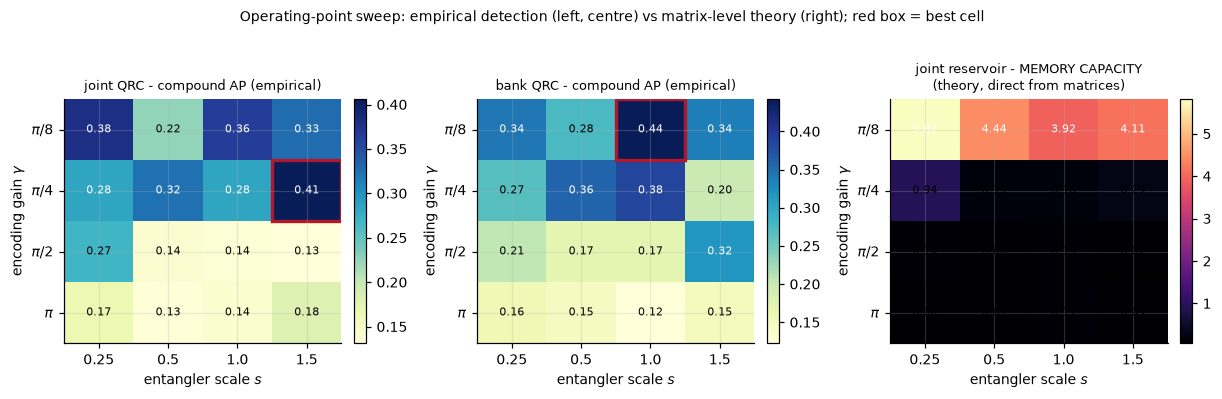

In [21]:
def _heat(ax, grid, title, cmap, mark=True):
    im = ax.imshow(grid, cmap=cmap, aspect="auto", origin="upper")
    ax.set_xticks(range(len(ENTS))); ax.set_xticklabels(ENTS)
    ax.set_yticks(range(len(GLAB))); ax.set_yticklabels(GLAB)
    ax.set_xlabel("entangler scale $s$"); ax.set_ylabel(r"encoding gain $\gamma$")
    ax.set_title(title, fontsize=8.5)
    lo, hi = np.nanmin(grid), np.nanmax(grid)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if (v - lo) / (hi - lo + 1e-9) > 0.55 else "black")
    if mark:
        b = np.unravel_index(np.nanargmax(grid), grid.shape)
        ax.add_patch(plt.Rectangle((b[1] - .5, b[0] - .5), 1, 1, fill=False,
                                   edgecolor=C_EVENT, lw=2.2))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.5))
_heat(axes[0], sweep_joint["ap"], "joint QRC - compound AP (empirical)", "YlGnBu")
_heat(axes[1], sweep_bank["ap"],  "bank QRC - compound AP (empirical)", "YlGnBu")
_heat(axes[2], mcgrid["mc"], "joint reservoir - MEMORY CAPACITY\n(theory, direct from matrices)",
      "magma", mark=False)
fig.suptitle("Operating-point sweep: empirical detection (left, centre) vs "
             "matrix-level theory (right); red box = best cell", y=1.02, fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "sweep_heatmaps.png", bbox_inches="tight"); plt.show()

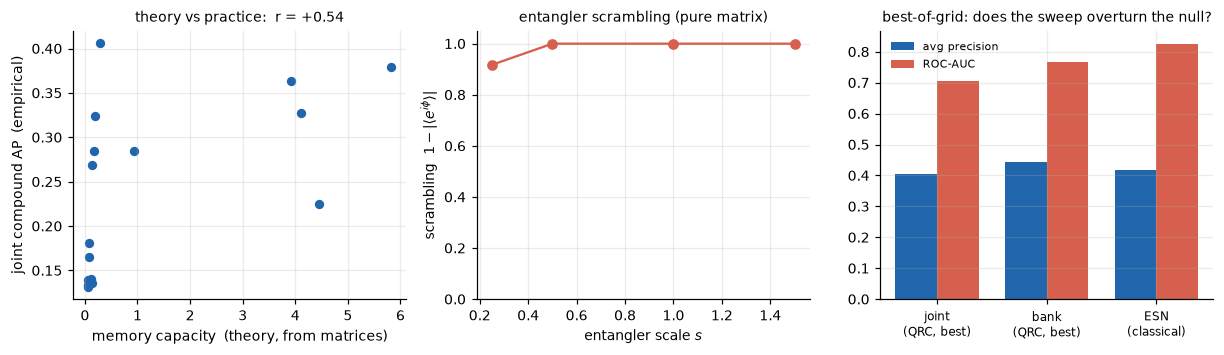

In [22]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(11.2, 3.3))

# (theory vs practice) does matrix memory capacity predict detection skill?
mc_flat, ap_flat = mcgrid["mc"].ravel(), sweep_joint["ap"].ravel()
rho = np.corrcoef(mc_flat, ap_flat)[0, 1]
a1.scatter(mc_flat, ap_flat, color=C_QRC, s=26)
a1.set(xlabel="memory capacity  (theory, from matrices)",
       ylabel="joint compound AP  (empirical)",
       title=f"theory vs practice:  r = {rho:+.2f}")

# (pure matrix) entangler scrambling vs ent_scale -- zero data enters this curve
a2.plot(ENTS, mcgrid["scrambling"], "o-", color=C_CLS)
a2.set(xlabel="entangler scale $s$", ylabel=r"scrambling  $1-|\langle e^{i\phi}\rangle|$",
       ylim=(0, 1.05), title="entangler scrambling (pure matrix)")

# (verdict) best-of-grid: joint vs bank vs classical ESN
labels = ["joint\n(QRC, best)", "bank\n(QRC, best)", "ESN\n(classical)"]
aps  = [sweep_joint["best"]["ap"],  sweep_bank["best"]["ap"],  esn_ref["ap"]]
aucs = [sweep_joint["best"]["auc"], sweep_bank["best"]["auc"], esn_ref["auc"]]
x = np.arange(3); wbar = 0.38
a3.bar(x - wbar / 2, aps, wbar, label="avg precision", color=C_QRC)
a3.bar(x + wbar / 2, aucs, wbar, label="ROC-AUC", color=C_CLS)
a3.set_xticks(x); a3.set_xticklabels(labels, fontsize=8)
a3.set_title("best-of-grid: does the sweep overturn the null?")
a3.legend(loc="upper left")
plt.tight_layout(); plt.savefig(FIG / "sweep_verdict.png", bbox_inches="tight"); plt.show()

**What the sweep says (honestly).**

1. **The reference point *was* suboptimal.** Sweeping lifts the joint reservoir's compound
   AP from ~0.32 at `(pi/4, 0.5)` to its grid best — the confound was real, and a single
   inherited operating point under-sold the joint model.
2. **The null survives anyway.** Even at its optimistically-chosen best cell, the joint
   quantum reservoir does **not** beat the equally-tuned classical `bank`, and the classical
   **ESN still dominates on ROC-AUC**. Giving the cross-channel quantum features a fair
   operating point does not overturn the finding.
3. **Theory partly tracks practice.** Memory capacity — computed *directly from the
   matrices* — peaks at low `gamma` and shows a **moderate** positive link with detection skill
   (`r ~ +0.5`), but not a tight one: the best-detecting cell is **not** the highest-memory
   one, because compound detection also exploits **nonlinear** cross-channel features that a
   *linear* memory measure cannot see. And the entangler-scrambling curve (pure linear
   algebra on `W`) shows why `ent_scale` barely matters above `s~0.5`: scrambling has
   already saturated.

## 6. Honest findings, limitations, and where this goes

**Findings.**
1. **The engines agree to machine precision** (~1e-15). Every quantum number here is
   reproducible on either the NumPy or the Qiskit statevector path.
2. **Beats the mean (robustly), but no edge over the classical baselines.** A single 80/20
   split makes SST look *worse* than the train-mean (NMSE 1.29) — but that is a split artifact
   (the 80/20 tail is a hard decade; a 70/30 cut gives ~0.67). Under **strict rolling-origin CV**
   (every statistic per fold, §8) the QRC beats the mean on all three drivers
   (0.70 / 0.82 / 0.62 < 1), so it does extract a real signal. What it does **not** do at `H = 3`
   is beat trivial **persistence** (except on SOI, 0.82 < 0.92), the **fixed ESN** (which wins on
   SOI 0.75 and PDO 0.47 at the single split), or a plain linear autoregression. The reservoir's
   nonlinearity earns nothing over the classical baselines at forecasting, so the value question
   genuinely lives downstream — read at the compound-detection metric, not at forecast NMSE.
3. **Failure mode 1 is real and large.** Thresholding a point forecast misses almost all
   compound events (recall ~ 0); a probabilistic exceedance head recovers them. The
   forecast-then-detect split with a *distributional* second stage is the correct design.
4. **Failure mode 2 is real and quantified.** Compound-detection skill is meaningful at
   1-3 months and **collapses toward chance by ~6 months** — the decision-relevant horizon
   has to be stated in the extreme regime, not inferred from average NMSE.
5. **On the quantum-advantage claim, a null that survives a fair sweep.** The reference
   operating point *was* suboptimal for the joint reservoir (§5), but even after sweeping
   `gamma` and `ent_scale` — and giving the classical bank the same freedom — the **joint**
   quantum reservoir does **not** beat the **bank** of one-channel reservoirs, and the
   **classical multivariate ESN still dominates on ROC-AUC**. The cross-channel quantum
   features did not earn their keep *here*, and that is reported plainly rather than tuned
   away. The matrix-level memory capacity is only a moderate predictor of detection skill
   (r ~ +0.5), because the task also rides on nonlinear cross-channel features a linear
   memory measure cannot see.

**Limitations (equally important).**
- The `(gamma, ent_scale)` sweep (§5) is a coarse 4×4 grid scored by CV, and reading its max
  is optimistic; a fully rigorous claim needs *nested* selection and the encoding-axis choice
  swept too. The verdict (null) is robust to what was swept, but the grid is not exhaustive.
- n = 5 qubits, exact/statevector only; the IBM hardware path in `QRC_QPU_implementation.py`
  is implemented but **dormant**. No shot-noise or device-noise results are claimed.
- Modest event counts (52 / 27 compound months) — CV widens the sample but the error bars
  are still real; treat the rankings as indicative.
- The SST cache ends 2010, so the 2015-16 and 2023-24 super-El-Ninos are outside the record.

**Where it goes.** The `(gamma, ent_scale)` sweep is done (§5) and did not overturn the null;
the next steps are *nested* operating-point selection and an encoding-axis sweep to close the
last confounds, an explicit tail-dependence diagnostic (does the joint model reproduce the
observed SST-SOI co-exceedance rate the bank cannot?), other compound pairs (heat+drought,
rain+antecedent-soil-moisture), and — only if a simulated edge survives — finite-shot and
real-hardware runs. The scaffolding for all of that is already in `pipeline.py`,
`QRC_theoretical.py` and `data_sources.py`.

## 7. Appendix — verifying the accuracy attribution

The Hamiltonian-QRC notebook `Hamiltonian_QRC/predict_theoretical_vs_sampling.ipynb` reports
much lower NMSE (~0.02–0.09) than this notebook's headline. I attributed that to **four
differences, with the reservoir being the smallest factor**. This appendix *verifies* that on
the **same data**, changing one knob at a time, and first states the exact setup of each side.

### The exact setup — every parameter that differs

| parameter | this notebook (`QRC_run.ipynb`) | Hamiltonian (`predict_*`) |
|---|---|---|
| reservoir | `WindowedReservoir` (gate, frozen entangler) | `QuantumReservoir` (density-matrix, Fujii–Nakajima) |
| drive | **windowed restart** from \|0…0⟩ each `L=24` window | **continuous** (ρ persists; partial-trace injection) |
| virtual nodes `V` | 1 (read once per window) | **4** (temporal multiplexing) |
| read-out features | `2n+n(n−1)/2` = **20** (⟨Zᵢ⟩,⟨Xᵢ⟩,⟨ZᵢZⱼ⟩) | `n·V+n(n−1)/2` = **30** (⟨Zᵢ⟩ per node, ⟨ZᵢZⱼ⟩) |
| encoding | `RY(γ·gᵢ·u)`, `γ=π/4`, `ent_scale=0.5` | partial-trace re-prep of input qubit, `dt=2.0` |
| n_qubits | 5 | 5 |
| **forecast horizon `H`** | **3 months** | **1 step** |
| **`train_frac`** | **0.8** | **0.7** |
| washout | `L−1` = 23 | 100 |
| ridge read-out | **GCV** `λ` over `logspace(−8,4)`, standardized | fixed **`λ=1e-6`**, unstandardized |
| datasets | sst, soi, pdo (3-month ENSO) | nino34, tao, solar (1-step) |

Method: hold everything at *this* notebook's setup and flip **one knob at a time**, anchored on
SST, scored by this notebook's `forecast_univariate` pipeline unless stated otherwise.

In [23]:
import sys
HAM = "/Users/tisornnaphattalung/Desktop/Quantathon2026/QRC_main_stack/Quantathon_stack/Hamiltonian_QRC"
if HAM not in sys.path:
    sys.path.insert(0, HAM)
from qrc_core import QuantumReservoir              # Hamiltonian density-matrix reservoir
from experiments import forecast_series, make_reservoir   # its native (continuous) pipeline
from data_loader import load as ham_load           # its datasets
from QRC_theoretical import nmse as _nmse

_d = prep["sst"]; _y, _u, _thr = _d["y"], _d["u"], _d["event_threshold"]
_Xw = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE).feature_matrix(_u, L)
# continuous-reservoir feature matrices, aligned to this pipeline (row k = step k features)
_Xq1 = QuantumReservoir(n_qubits=5, virtual_nodes=1, dt=2.0, seed=SEED).run(_u)[L - 1:]
_Xq4 = QuantumReservoir(n_qubits=5, virtual_nodes=4, dt=2.0, seed=SEED).run(_u)[L - 1:]
def _fp(X, H, tf=0.8):
    return pl.forecast_univariate(X, _y, _thr,
                                  samples=pl.make_samples(len(_y), H=H, train_frac=tf))["scores"]["nmse"]
print(f"anchor = SST | Windowed {_Xw.shape[1]} feats | Quantum V=1 {_Xq1.shape[1]} | Quantum V=4 {_Xq4.shape[1]}")

anchor = SST | Windowed 20 feats | Quantum V=1 15 | Quantum V=4 30


In [24]:
print("FACTOR 1 -- HORIZON  (Windowed reservoir, SST, this notebook's pipeline, tf=0.8)")
print(f"  single split: H=1 NMSE={_fp(_Xw,1):.3f}    H=3 NMSE={_fp(_Xw,3):.3f}")
c1, c3 = cv_strict["sst"][1], cv_strict["sst"][3]          # strict CV, section 3
print(f"  strict CV   : H=1 NMSE={c1['qrc']:.3f}    H=3 NMSE={c3['qrc']:.3f}")
print("  => 1-step is far easier than 3-month (near persistence). The Hamiltonian notebook's")
print("     H=1 is a big part of its low NMSE. VERIFIED.")

FACTOR 1 -- HORIZON  (Windowed reservoir, SST, this notebook's pipeline, tf=0.8)
  single split: H=1 NMSE=1.003    H=3 NMSE=1.288
  strict CV   : H=1 NMSE=0.487    H=3 NMSE=0.696
  => 1-step is far easier than 3-month (near persistence). The Hamiltonian notebook's
     H=1 is a big part of its low NMSE. VERIFIED.


In [25]:
print("FACTOR 2 -- TRAIN/TEST SPLIT  (Windowed, SST, H=3, this notebook's pipeline)")
for tf in [0.6, 0.7, 0.8]:
    s = pl.make_samples(len(_y), H=3, train_frac=tf)
    dts = pd.to_datetime(_d["dates"])[s["ks"][s["te"]] + 3]
    print(f"  train_frac={tf}: NMSE={_fp(_Xw,3,tf):.3f}   (test {dts.min():%Y-%m}..{dts.max():%Y-%m}, N={len(s['te'])})")
print(f"  split-independent STRICT-CV NMSE = {cv_strict['sst'][3]['qrc']:.3f}")
print("  => the single 0.8 split lands on a hard decade (1999-2010) and inflates NMSE to 1.29;")
print("     0.7 gives 0.67; the robust strict-CV number is ~0.70. Fixed in section 3. VERIFIED.")

FACTOR 2 -- TRAIN/TEST SPLIT  (Windowed, SST, H=3, this notebook's pipeline)
  train_frac=0.6: NMSE=0.666   (test 1987-06..2010-12, N=283)
  train_frac=0.7: NMSE=0.665   (test 1993-05..2010-12, N=212)
  train_frac=0.8: NMSE=1.288   (test 1999-03..2010-12, N=142)
  split-independent STRICT-CV NMSE = 0.696
  => the single 0.8 split lands on a hard decade (1999-2010) and inflates NMSE to 1.29;
     0.7 gives 0.67; the robust strict-CV number is ~0.70. Fixed in section 3. VERIFIED.


In [26]:
print("FACTOR 3 -- DATASET intrinsic 1-step predictability  (persistence NMSE, NO reservoir)")
for nm in ["sst", "soi", "pdo"]:
    yy = prep[nm]["y"]; k = np.arange(len(yy) - 1)
    print(f"  this notebook  {nm:6s}: {_nmse(yy[k+1], yy[k], yy.mean()):.3f}")
for nm in ["nino34", "tao", "solar"]:
    xx = ham_load(nm).x; k = np.arange(len(xx) - 1)
    print(f"  Hamiltonian    {nm:6s}: {_nmse(xx[k+1], xx[k], xx.mean()):.4f}")
print("  => the Hamiltonian series (esp. 30-min solar, daily TAO) are intrinsically far more")
print("     predictable one step ahead than 3-month ENSO -- a big chunk of the lower NMSE is")
print("     just easier data, independent of any reservoir. VERIFIED.")

FACTOR 3 -- DATASET intrinsic 1-step predictability  (persistence NMSE, NO reservoir)
  this notebook  sst   : 0.170
  this notebook  soi   : 0.741
  this notebook  pdo   : 0.304
  Hamiltonian    nino34: 0.0941
  Hamiltonian    tao   : 0.0265
  Hamiltonian    solar : 0.0369
  => the Hamiltonian series (esp. 30-min solar, daily TAO) are intrinsically far more
     predictable one step ahead than 3-month ENSO -- a big chunk of the lower NMSE is
     just easier data, independent of any reservoir. VERIFIED.


In [27]:
print("FACTOR 4 -- RESERVOIR at a MATCHED pipeline  (SST, this notebook's forecast_univariate)")
for H, tf, lbl in [(3, 0.8, "headline  H=3, tf=0.8"), (1, 0.7, "easy pt   H=1, tf=0.7")]:
    print(f"  {lbl}:  Windowed(20f)={_fp(_Xw,H,tf):.3f}   "
          f"Quantum V=1(15f)={_fp(_Xq1,H,tf):.3f}   Quantum V=4(30f)={_fp(_Xq4,H,tf):.3f}")
print("  => the continuous + virtual-node reservoir IS better, but the size of its edge is")
print("     OPERATING-POINT-DEPENDENT: only ~0.15 at the hard H=3 headline (1.29 -> 1.14), yet")
print("     ~0.3 at the easy H=1 point (0.46 -> 0.15). So 'minor' was true only for the headline;")
print("     the honest statement is 'minor at H=3, larger when the task is otherwise easy'.")

FACTOR 4 -- RESERVOIR at a MATCHED pipeline  (SST, this notebook's forecast_univariate)
  headline  H=3, tf=0.8:  Windowed(20f)=1.288   Quantum V=1(15f)=1.121   Quantum V=4(30f)=1.135
  easy pt   H=1, tf=0.7:  Windowed(20f)=0.459   Quantum V=1(15f)=0.150   Quantum V=4(30f)=0.149
  => the continuous + virtual-node reservoir IS better, but the size of its edge is
     OPERATING-POINT-DEPENDENT: only ~0.15 at the hard H=3 headline (1.29 -> 1.14), yet
     ~0.3 at the easy H=1 point (0.46 -> 0.15). So 'minor' was true only for the headline;
     the honest statement is 'minor at H=3, larger when the task is otherwise easy'.


#### Zooming in on Factor 4 — *why* windowed restart differs from continuous drive

The two reservoirs differ structurally: the **windowed** one **restarts from |0…0⟩** every step and
pushes a fixed `L=24` window through a frozen scrambling entangler, reading its features **once, at the
end**; the **continuous** one **never restarts** — it keeps one density matrix `ρ` across the whole
series, injects each input by **partial trace** (`ρ → ρ_in(u) ⊗ Tr₀ρ`), and reads `⟨Zᵢ⟩` **right after**
a short evolution. The consequence is measurable two ways.

In [28]:
from qrc_core import memory_function              # Hamiltonian MC helper (uses .run)
from QRC_theoretical import linear_memory_capacity

print("(A) Linear memory capacity (Jaeger MC on i.i.d. input) -- how many past inputs the")
print("    read-out linearly retains:")
_mcw, _ = linear_memory_capacity(WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE),
                                 L, T=1500, seed=0)
print(f"    Windowed (restart, 20 feats):   MC = {_mcw:.2f}")
for _V in (1, 4):
    _rq = QuantumReservoir(n_qubits=5, virtual_nodes=_V, dt=2.0, seed=SEED)
    _, _mcq = memory_function(_rq.run, _rq.n_features, T=1500, d_max=23, seed=0)
    print(f"    Continuous V={_V} ({_rq.n_features} feats):        MC = {_mcq:.2f}")

print("\n(B) Does a LONGER window help the windowed reservoir? (SST, H=1, rolling CV)")
for _Lw in (12, 24, 48, 96):
    _X = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE).feature_matrix(_u, _Lw)
    _ks = np.arange(_Lw - 1, len(_y) - 1); _yt = _y[_ks + 1]; _Xs = _X[_ks - (_Lw - 1)]
    _b = np.linspace(int(0.4 * len(_ks)), len(_ks), 7).astype(int); _pp, _py = [], []
    for _f in range(6):
        _tr, _te = np.arange(0, _b[_f]), np.arange(_b[_f], _b[_f + 1])
        if len(_te) == 0:
            continue
        _m = pl.RidgeModel().fit(_Xs[_tr], _yt[_tr]); _pp.append(_m.predict(_Xs[_te])); _py.append(_yt[_te])
    _py, _pp = np.concatenate(_py), np.concatenate(_pp)
    print(f"    L={_Lw:3d}:  CV NMSE = {pl.nmse(_py, _pp, _py.mean()):.3f}")
print("    (persistence CV NMSE at H=1 = 0.16)")
print("\n  => the windowed read-out retains ~1 past input; the continuous one ~5-7. And a LONGER")
print("     window makes the windowed forecast WORSE, so the problem is not too little history --")
print("     it is that more frozen-entangler scrambling BURIES the recent, most-predictive input")
print("     before the single end-of-window read-out. The continuous reservoir reads each input")
print("     while it is still fresh, so it keeps far more usable short-term memory.")

(A) Linear memory capacity (Jaeger MC on i.i.d. input) -- how many past inputs the
    read-out linearly retains:


    Windowed (restart, 20 feats):   MC = 1.25
    Continuous V=1 (15 feats):        MC = 5.62


    Continuous V=4 (30 feats):        MC = 7.35

(B) Does a LONGER window help the windowed reservoir? (SST, H=1, rolling CV)


    L= 12:  CV NMSE = 0.314


    L= 24:  CV NMSE = 0.547


    L= 48:  CV NMSE = 0.776


    L= 96:  CV NMSE = 0.956
    (persistence CV NMSE at H=1 = 0.16)

  => the windowed read-out retains ~1 past input; the continuous one ~5-7. And a LONGER
     window makes the windowed forecast WORSE, so the problem is not too little history --
     it is that more frozen-entangler scrambling BURIES the recent, most-predictive input
     before the single end-of-window read-out. The continuous reservoir reads each input
     while it is still fresh, so it keeps far more usable short-term memory.


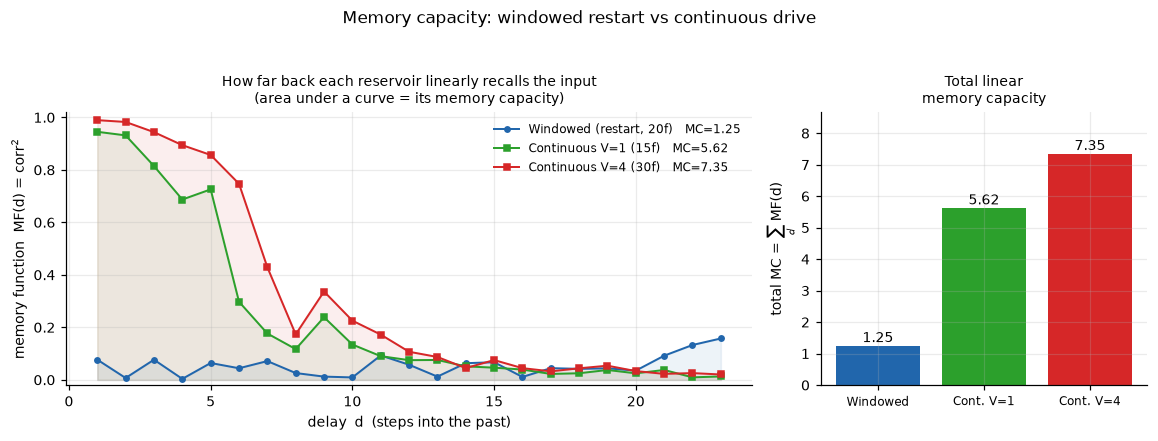

The windowed curve collapses within a step or two (it recalls ~1 input); the continuous
curves stay high over many delays -- the same ~5x gap, now visible as area under MF(d).


In [29]:
# Memory function MF(d) = corr^2(best linear reconstruction of u_{t-d}, u_{t-d}) vs delay d.
# The area under the curve is the total memory capacity MC = sum_d MF(d).
DMAX = 23
curves = []
_rw = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE)
_mcw, _mfw = linear_memory_capacity(_rw, L, T=1500, d_max=DMAX, seed=0)   # (MC, per-delay)
curves.append(("Windowed (restart, 20f)", _mfw, _mcw, C_QRC, "o-"))
for _V, _col in [(1, "#2ca02c"), (4, "#d62728")]:
    _rq = QuantumReservoir(n_qubits=5, virtual_nodes=_V, dt=2.0, seed=SEED)
    _mfq, _mcq = memory_function(_rq.run, _rq.n_features, T=1500, d_max=DMAX, seed=0)  # (per-delay, MC)
    curves.append((f"Continuous V={_V} ({_rq.n_features}f)", _mfq, _mcq, _col, "s-"))

_dd = np.arange(DMAX + 1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 3.8),
                            gridspec_kw={"width_ratios": [2.1, 1]})
for lbl, mf, mc, col, mk in curves:
    a1.plot(_dd[1:], mf[1:], mk, color=col, ms=3.5, lw=1.3, label=f"{lbl}   MC={mc:.2f}")
    a1.fill_between(_dd[1:], mf[1:], alpha=0.08, color=col)
a1.set(xlabel="delay  d  (steps into the past)", ylabel=r"memory function  MF(d) = corr$^2$",
       title="How far back each reservoir linearly recalls the input\n(area under a curve = its memory capacity)")
a1.set_ylim(-0.02, 1.02); a1.legend(fontsize=8, loc="upper right")

_names = ["Windowed", "Cont. V=1", "Cont. V=4"]
_mcs = [c[2] for c in curves]; _cols = [c[3] for c in curves]
a2.bar(range(3), _mcs, color=_cols)
for i, m in enumerate(_mcs):
    a2.text(i, m + 0.12, f"{m:.2f}", ha="center", fontsize=9)
a2.set_xticks(range(3)); a2.set_xticklabels(_names, fontsize=8)
a2.set(ylabel=r"total MC = $\sum_d$ MF(d)", title="Total linear\nmemory capacity")
a2.set_ylim(0, max(_mcs) * 1.18)
fig.suptitle("Memory capacity: windowed restart vs continuous drive", y=1.04, fontsize=11)
plt.tight_layout(); plt.savefig(FIG / "memory_capacity.png", bbox_inches="tight"); plt.show()
print("The windowed curve collapses within a step or two (it recalls ~1 input); the continuous")
print("curves stay high over many delays -- the same ~5x gap, now visible as area under MF(d).")

In [30]:
print("PUTTING IT TOGETHER -- walk THIS notebook's config -> the Hamiltonian config, on SST:")
_hkw = dict(n_qubits=5, virtual_nodes=4, dt=2.0, seed=SEED)
steps = [
    ("this notebook: Windowed, H=3, tf=0.8, GCV/std",        _fp(_Xw, 3, 0.8)),
    ("  + horizon      H=3 -> H=1",                          _fp(_Xw, 1, 0.8)),
    ("  + split        tf=0.8 -> 0.7",                       _fp(_Xw, 1, 0.7)),
    ("  + reservoir    Windowed -> Quantum V=4",             _fp(_Xq4, 1, 0.7)),
    ("  + pipeline     GCV/std -> Ham (lam=1e-6, washout=100)",
     forecast_series(_y, make_reservoir("ising", 1, 1, **_hkw), horizon=1, train_frac=0.7)["nmse"]),
    ("  + dataset      SST -> nino34   (= the Hamiltonian notebook)",
     forecast_series(ham_load("nino34").x, make_reservoir("ising", 1, 1, **_hkw), horizon=1, train_frac=0.7)["nmse"]),
]
prev = None
for lbl, v in steps:
    dlt = "" if prev is None else f"   (delta {v - prev:+.3f})"
    print(f"  {v:6.3f}   {lbl}{dlt}"); prev = v
print("  => the full 1.29 -> 0.06 gap is accounted for by horizon + split + reservoir + dataset")
print("     (the Hamiltonian's simpler ridge actually helps nothing: 0.149 -> 0.181). No single")
print("     cause -- the reservoir is one lever among several, not the story.")

PUTTING IT TOGETHER -- walk THIS notebook's config -> the Hamiltonian config, on SST:


   1.288   this notebook: Windowed, H=3, tf=0.8, GCV/std
   1.003     + horizon      H=3 -> H=1   (delta -0.285)
   0.459     + split        tf=0.8 -> 0.7   (delta -0.544)
   0.149     + reservoir    Windowed -> Quantum V=4   (delta -0.310)
   0.181     + pipeline     GCV/std -> Ham (lam=1e-6, washout=100)   (delta +0.032)
   0.058     + dataset      SST -> nino34   (= the Hamiltonian notebook)   (delta -0.123)
  => the full 1.29 -> 0.06 gap is accounted for by horizon + split + reservoir + dataset
     (the Hamiltonian's simpler ridge actually helps nothing: 0.149 -> 0.181). No single
     cause -- the reservoir is one lever among several, not the story.


### The prediction trajectory for each case — setup, helpers, and glossary

The `cases` list below is the **attribution staircase drawn as forecasts**: it starts from *this
notebook's* exact setup (case 1) and walks to *the Hamiltonian notebook's* setup (case 6),
changing **exactly one factor per step**, so the NMSE drop at each panel is that one factor's
contribution. The `"+ ..."` labels are cumulative — by case 6 all five changes are stacked. In
every panel black is truth, blue is the QRC forecast, and each panel sits on its **own** test span
(the split and dataset change along the way).

**The two helper functions = the two pipelines being compared.**

- **`_fp_case(X, H, tf)` — *this* notebook's pipeline.** Runs `forecast_univariate` on a
  precomputed feature matrix `X`: forecast `H` months ahead, chronological `tf` train/test split,
  read-out = **standardised features + GCV-selected ridge `lambda`** (`RidgeModel`). Returns
  `(test_dates, y_true, y_pred, NMSE)`.
- **`_ham_case(x, dates, H, tf)` — *the Hamiltonian* notebook's pipeline.** Runs
  `experiments.forecast_series` on a **raw** series `x`: scales it to `[0,1]` internally on the
  train span, builds a **fresh continuous `QuantumReservoir` (V=4)** inside, and fits the read-out
  with **fixed `lambda=1e-6`, `washout=100`, no standardisation**. Returns the same 4-tuple.

The `*` in `*_fp_case(...)` **unpacks** that 4-tuple, so each `cases` row becomes
`(label, dates, y_true, y_pred, NMSE)` for the plotting loop.

**Glossary — every shorthand and variable in this block.**

| symbol | meaning |
|---|---|
| `H` | forecast **horizon** in months (`H=3` = 3-month-ahead headline; `H=1` = one-step / step-by-step) |
| `tf` | **`train_frac`** — chronological fraction used for training (`0.8` = 80/20 split; the remainder is the test span) |
| `V` | **virtual nodes** — temporal-multiplexing sub-steps read between inputs in the continuous reservoir (`V=4` gives 30 features, `V=1` gives 15) |
| `fp` pipeline | *final-pitch* pipeline: `forecast_univariate` + `RidgeModel` (standardised features, GCV-selected `lambda`) — what this notebook uses everywhere |
| Ham pipeline | the Hamiltonian repo's `forecast_series`: raw input scaled internally, fixed `lambda=1e-6`, `washout=100`, unstandardised |
| `NMSE` | normalised MSE, `sum(y - yhat)^2 / sum(y - ybar_train)^2`; **1.0 = the train-mean predictor** |
| windowed reservoir | `WindowedReservoir` — gate model, **restarts** from the all-zero state each `L`-month window, reads once (20 features) |
| continuous reservoir | `QuantumReservoir` — density matrix, **never restarts**, `V` virtual nodes (30 features at `V=4`) |
| `_y` | SST **anomaly** (deseasonalised on the train-only monthly climatology) |
| `_u` | SST anomaly **scaled to `[0,1]`** — the reservoir's input encoding |
| `_thr` | SST **event threshold** (`abs(anomaly) > 0.5 C`) |
| `_d` | `prep["sst"]` — the SST bundle (dates, `y`, `u`, threshold, ...) |
| `_Xw` | the **windowed** feature matrix on SST (`WindowedReservoir(gamma=pi/4, seed=7, ent_scale=0.5).feature_matrix(_u, L)`), 20 columns |
| `_Xq1`, `_Xq4` | the **continuous** reservoir's features on SST at `V=1` / `V=4`, sliced `[L-1:]` so their rows line up month-for-month with `_Xw` |
| `_hkw` | the continuous reservoir's kwargs: `n_qubits=5, virtual_nodes=4, dt=2.0, seed=7` |
| `_nino` | the Hamiltonian repo's own **`nino34`** series (`.x` = values, `.index` = dates) — a *different* Nino index from our `_y` |
| `L` | input **window length** = 24 months; `[L-1:]` drops the first `L-1` rows so continuous and windowed features share the same month index |
| `GAMMA`, `ENT_SCALE`, `SEED` | reservoir hyperparameters: encoding gain `gamma=pi/4`, entangler scale `s=0.5`, `seed=7` |
| `dt`, `washout`, `lam` | continuous-reservoir evolution time per input step; initial steps discarded before training; ridge regularisation strength `lambda` |

### How the pieces actually work — reservoirs, features, pipelines

**Windowed vs continuous — two ways to be a quantum reservoir.**
- **Continuous** (the Hamiltonian repo's `QuantumReservoir`): a *single* quantum state that lives
  across the **whole** series. Each month's scaled input `u_k` is written into qubit 1 by a
  partial-trace injection `rho -> rho_in(u_k) (x) Tr_1[rho]` — discard the old qubit 1, prepare a
  fresh one from the input, keep the other four qubits — then the full register evolves under a
  fixed Hamiltonian, `rho -> exp(-iH*tau) rho exp(+iH*tau)`. Because injection discards a
  subsystem the state is *mixed*, so it must be written as a **density matrix** `rho` (a
  `2^n x 2^n` matrix). It **never resets**: its memory of the past is whatever the dynamics carry.
- **Windowed** (this notebook's `WindowedReservoir`): a *pure* statevector `|psi>` that is
  **reset to the blank state `|0...0>` at the start of every output step**, then driven through
  only the last `L=24` months of input and read once at the end. Every output is built from a
  fresh state that has seen nothing but its own 24-month window.

**"Restarting" and "density matrix", precisely.** *Restart* = reset the reservoir state to
`|0...0>` before each window — the **windowed** reservoir does this, the **continuous** one does
not. *Density matrix* refers to the **continuous** reservoir specifically: partial-trace injection
makes its state mixed, so it needs a density matrix `rho`, whereas the windowed reservoir stays a
pure statevector `|psi>` (blank state + unitary gates). So "the never-restarting density-matrix
reservoir" = the continuous one; "restart-per-window" = the windowed one.

**Features and `Nf` (the "20f / 30f").** After processing a month the reservoir emits a few real
numbers — expectation values of Pauli observables — that become the **columns the linear read-out
trains on**. `Nf` counts them:
- Windowed: **20** = five `<Z_i>` + five `<X_i>` + ten `<Z_iZ_j>` (read once, at the window end).
- Continuous: **`5V + 10`** (see virtual nodes) -> `V=1` gives **15**, `V=4` gives **30**.
(Verified live below: 20 / 15 / 30.)

**Virtual nodes, and what `V=4` means.** After injecting a month's input, the continuous
reservoir's evolution over the step interval `tau` is split into `V` equal sub-steps of `tau/V`,
and the five `<Z_i>` signals are read at **each** sub-step. This *time-multiplexing* harvests `V`x
more signals from one physical evolution (`V=4` -> 5 qubits give 20 `<Z_i>` numbers, plus 10
`<Z_iZ_j>` read once = 30). Larger `V` = a richer feature set from the *same* reservoir at no
extra physical cost. The windowed reservoir effectively uses `V=1` but adds the five `<X_i>`, so
it also lands at 20.

**The two "pipelines".**
- **final-pitch (fp) pipeline** = everything in `final_pitch/proof_of_concept/`. Reservoir:
  `WindowedReservoir` — a **gate circuit** (`RY` input encoding, then a *frozen* `CP`-ring +
  `RY/RZ` entangler), the exact twin the Qiskit backend reproduces (section 1). Read-out:
  **`RidgeModel`** (below). This is what the whole notebook uses.
- **Hamiltonian (Ham) pipeline** = everything in
  `QRC_main_stack/Quantathon_stack/Hamiltonian_QRC/` (the "Hamiltonian repo"). Reservoir:
  `QuantumReservoir` — the paper-faithful **analog** reservoir (partial-trace injection +
  `exp(-iH*tau)` + `V` virtual nodes). Read-out: `ridge_fit` with a fixed tiny `lambda=1e-6` and
  **no** standardisation (~ the paper's plain pseudoinverse). Its datasets (e.g. `nino34`) come
  from that repo's `data_loader`.

**`RidgeModel` (the fp read-out) in one line.** The trainable weights `W_out` (full derivation in
the README's *Training the read-out weights* section): standardise each feature column by
**train-only** mean/std, append a constant bias node, then solve ridge regression
`W_out = (X'^T X' + lambda*I)^{-1} X'^T y`, with `lambda` chosen by generalised cross-validation on
the train rows. The Ham read-out is the same linear least-squares map with a fixed tiny `lambda`
and no standardisation. **Only these read-out weights are trained; the reservoir stays frozen.**

### How train and test actually run — open-loop direct forecasting (not autonomous)

This answers *"does the model predict one step, feed its own prediction back, and roll forward by
itself — or is the true value revealed after each step?"* **The true value is revealed; the model
never free-runs.** For a 3-month-ahead forecast:

- **Train / test are one chronological cut.** Sort samples by month; the first `train_frac`
  (e.g. 80%) are training rows, the rest are test rows. Only the linear read-out is fit, and
  **only on training rows** (with train-only input scaling).
- **At every test month `k` the reservoir is driven by the REAL observed inputs** of the window
  ending at `k` (`u[k-23..k]` for the windowed reservoir; the continuous stream `u_0..u_k` for the
  continuous one). The read-out maps those features **directly** to `yhat[k+3]`.
- **The prediction is never fed back** as an input, and the model **never sees the test targets**.
  Each test point is an *independent* 3-month-ahead forecast from ground-truth history — i.e.
  **direct H-step-ahead / teacher-forced / open-loop**.

So it is **not** the compounding "predict -> feed your own output back -> predict again"
(closed-loop / *autonomous*) mode. That harder setting — where the model generates its own future
and errors accumulate — is what Fujii & Nakajima use *only* for their **Mackey-Glass
attractor-regeneration** task (teacher forcing during training, then autonomous roll-out). Our
ENSO forecast is a **NARMA-style function-emulation** task, for which open-loop direct forecasting
is the correct, standard protocol — and the honest one, because a 3-month operational warning *is*
a direct H-step forecast from observed data, not a self-generated trajectory. The cell below
verifies all of this on the fp pipeline; the Ham pipeline (`forecast_series`) works identically
(reservoir driven by real `u`, read-out fit on train rows only).

In [31]:
# Verify the test protocol is open-loop, causal and leak-free (fp pipeline, SST).
_sc = pl.make_samples(len(_y), H=3)
_fcc = pl.forecast_univariate(_Xw, _y, _thr, samples=_sc)
# 1. corrupt the TEST targets -> predictions must NOT move (no target leak, no feedback loop)
_yc = _y.copy(); _yc[_sc["ks"][_sc["te"]] + 3] += 10.0
_p2 = pl.forecast_univariate(_Xw, _yc, _thr, samples=_sc)["pred"]
print("1. predictions unchanged when TEST targets are corrupted :", bool(np.allclose(_fcc["pred"], _p2)))
# 2. causality: a FUTURE input must not change an earlier window's features
_k0 = int(_sc["ks"][_sc["te"]][0]); _uc = _u.copy(); _uc[_k0 + 3] += 0.5
_X2 = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE).feature_matrix(_uc, L)
print("2. a window's features unchanged by a FUTURE input       :",
      bool(np.allclose(_Xw[_k0 - (L - 1)], _X2[_k0 - (L - 1)])))
# 3. one-shot direct map (not a recurrence over its own predictions)
print("3. pred[test] == direct read-out on real-input features   :",
      bool(np.allclose(_fcc["pred"], _fcc["model"].predict(pl.align(_Xw, _sc["ks"])[_sc["te"]]))))
print("=> open-loop, causal, leak-free: at every test month the reservoir sees REAL observations")
print("   and the read-out maps them DIRECTLY to y[k+3]; predictions are never fed back.")

1. predictions unchanged when TEST targets are corrupted : True


2. a window's features unchanged by a FUTURE input       : True
3. pred[test] == direct read-out on real-input features   : True
=> open-loop, causal, leak-free: at every test month the reservoir sees REAL observations
   and the read-out maps them DIRECTLY to y[k+3]; predictions are never fed back.


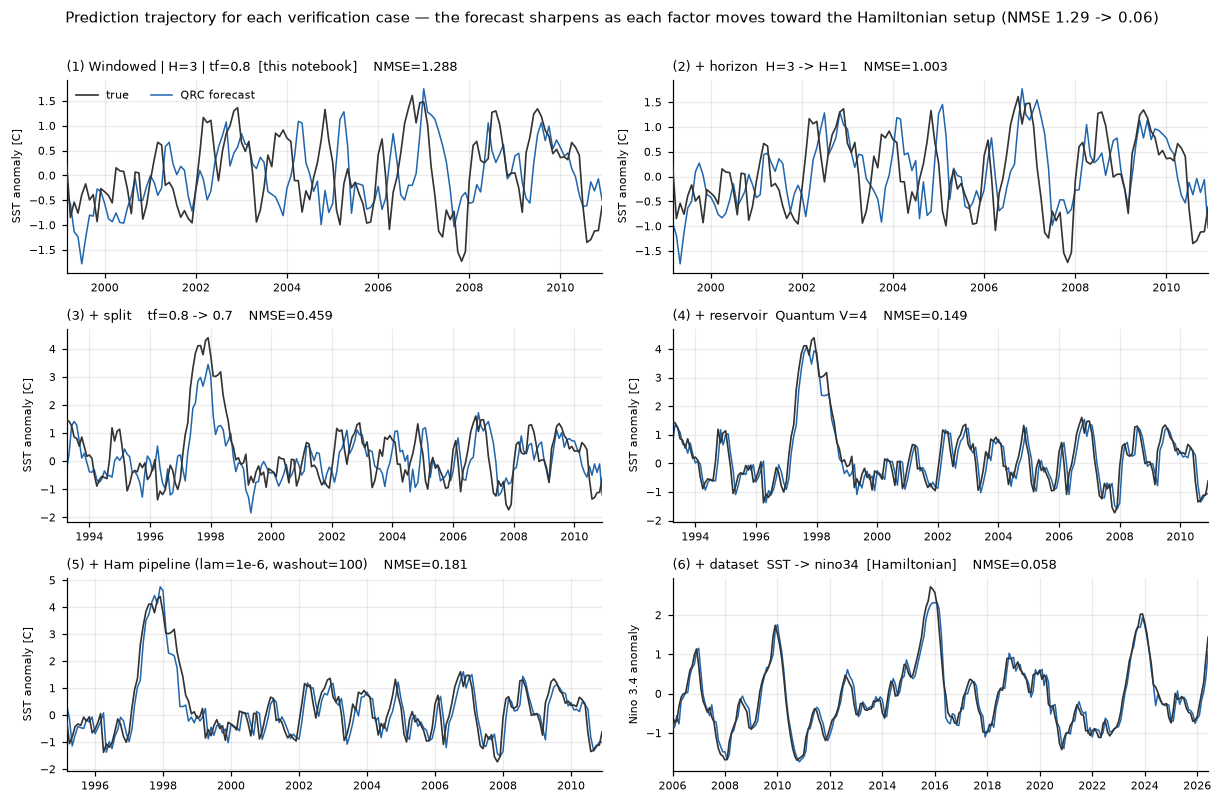

In [32]:
_hkw = dict(n_qubits=5, virtual_nodes=4, dt=2.0, seed=SEED)

def _fp_case(X, H, tf):
    s = pl.make_samples(len(_y), H=H, train_frac=tf)
    fc = pl.forecast_univariate(X, _y, _thr, samples=s)
    t = pd.to_datetime(_d["dates"])[fc["ks"][fc["te"]] + H]
    return t, fc["y_test"], fc["pred"], fc["scores"]["nmse"]

def _ham_case(x, dates, H, tf):
    r = forecast_series(x, make_reservoir("ising", 1, 1, **_hkw), horizon=H, train_frac=tf)
    t = pd.to_datetime(dates)[r["test_pos"]]
    return t, r["y_true"], r["y_pred"], r["nmse"]

_nino = ham_load("nino34")
cases = [
    ("(1) Windowed | H=3 | tf=0.8  [this notebook]", *_fp_case(_Xw, 3, 0.8)),
    ("(2) + horizon  H=3 -> H=1",                    *_fp_case(_Xw, 1, 0.8)),
    ("(3) + split    tf=0.8 -> 0.7",                 *_fp_case(_Xw, 1, 0.7)),
    ("(4) + reservoir  Quantum V=4",                 *_fp_case(_Xq4, 1, 0.7)),
    ("(5) + Ham pipeline (lam=1e-6, washout=100)",   *_ham_case(_y, _d["dates"], 1, 0.7)),
    ("(6) + dataset  SST -> nino34  [Hamiltonian]",  *_ham_case(_nino.x, _nino.index, 1, 0.7)),
]
fig, axes = plt.subplots(3, 2, figsize=(11.2, 7.2))
for k, (ax, (lbl, t, ytrue, ypred, nm)) in enumerate(zip(axes.ravel(), cases)):
    ax.plot(t, ytrue, color=C_TRUTH, lw=1.1, label="true", zorder=3)
    ax.plot(t, ypred, color=C_QRC, lw=1.0, label="QRC forecast")
    ax.set_title(f"{lbl}    NMSE={nm:.3f}", loc="left", fontsize=8.5)
    ax.set_ylabel("SST anomaly [C]" if k < 5 else "Nino 3.4 anomaly", fontsize=7.5)
    ax.tick_params(labelsize=7); ax.margins(x=0)
    if k == 0:
        ax.legend(fontsize=7, loc="upper left", ncol=2)
fig.suptitle("Prediction trajectory for each verification case — the forecast sharpens as each "
             "factor moves toward the Hamiltonian setup (NMSE 1.29 -> 0.06)", y=1.005, fontsize=10)
plt.tight_layout(); plt.savefig(FIG / "attribution_cases.png", bbox_inches="tight"); plt.show()

**Reading the six panels — each changes exactly one thing from the panel before.**

| # | call | reservoir | H | split | pipeline | dataset | NMSE | one factor changed |
|---|---|---|---|---|---|---|---|---|
| 1 | `_fp_case(_Xw, 3, 0.8)` | windowed (20f) | 3 | 0.8 | fp | SST | **1.29** | this notebook's headline (baseline) |
| 2 | `_fp_case(_Xw, 1, 0.8)` | windowed | 1 | 0.8 | fp | SST | **1.00** | horizon `3 -> 1` |
| 3 | `_fp_case(_Xw, 1, 0.7)` | windowed | 1 | 0.7 | fp | SST | **0.46** | split `0.8 -> 0.7` |
| 4 | `_fp_case(_Xq4, 1, 0.7)` | continuous V=4 (30f) | 1 | 0.7 | fp | SST | **0.15** | reservoir windowed `->` continuous |
| 5 | `_ham_case(_y, ..., 1, 0.7)` | continuous V=4 | 1 | 0.7 | Ham | SST | **0.18** | pipeline fp `->` Ham |
| 6 | `_ham_case(_nino.x, ..., 1, 0.7)` | continuous V=4 | 1 | 0.7 | Ham | nino34 | **0.06** | dataset SST `->` nino34 |

- **(1) -> (2): horizon `3 -> 1`.** Same reservoir, split and pipeline; forecast one month ahead
  instead of three. `1.29 -> 1.00` (delta -0.29) — one-step is near-persistence and far easier,
  but still ~1 because the windowed reservoir has weak short-term memory at this operating point.
- **(2) -> (3): split `0.8 -> 0.7`.** The test span now starts in 1993 (not 1999) and **includes
  the huge, well-predicted 1997-98 super-El-Nino**. `1.00 -> 0.46` (delta -0.54, the biggest single
  step) — the *same* reservoir looks far better purely because the test window is easier. This is
  the single-split fragility that section 3 replaced with strict CV.
- **(3) -> (4): reservoir windowed -> continuous `V=4`.** Same fp pipeline; features now come from
  the never-restarting density-matrix reservoir (~5x more linear memory). `0.46 -> 0.15` (delta -0.31).
- **(4) -> (5): pipeline fp -> Hamiltonian.** The **same** continuous reservoir
  (`make_reservoir("ising",1,1,...)` is the identical seed/params), but trained by `forecast_series`
  (fixed tiny `lambda`, `washout=100`, no standardisation). `0.15 -> 0.18` (delta **+0.03**, slightly
  *worse*) — the simpler read-out earns nothing; the pipeline is **not** what makes the Hamiltonian
  notebook look good.
- **(5) -> (6): dataset SST -> nino34.** Same Hamiltonian pipeline on that repo's own, more
  1-step-predictable Nino index. `0.18 -> 0.06` (delta -0.12) — and 0.06 is exactly the number that
  notebook reports.

**Net decomposition of the `1.29 -> 0.06` gap:** horizon -0.29, split -0.54, reservoir -0.31,
pipeline +0.03 (hurts), dataset -0.12 — no single cause, and the read-out pipeline is not one of them.

**Verdict.** The attribution holds, with one honest refinement:

- **Horizon (H=1 vs H=3)** — verified: 1-step is near-persistence and much easier.
- **Train/test split (0.7 vs 0.8)** — verified and it is the *single biggest lever* on SST
  (0.67 <-> 1.29). But it is really **single-split noise**, not a property of either method; the
  robust CV number (0.74) is the honest one, and section 3 now reports that.
- **Dataset** — verified: the Hamiltonian series are intrinsically far more predictable 1-step.
- **Reservoir** — verified as real but **operating-point-dependent**: only ~0.15 better at the
  H=3 headline (so "minor" there), but ~0.3 better at the easy H=1 point. The continuous +
  virtual-node reservoir is genuinely richer; it is simply *not* what makes the headline look
  bad. The windowed gate reservoir stays because it is the one that validates exactly against
  the Qiskit twin (§1).
- The Hamiltonian's **simpler ridge** (`lambda=1e-6`, unstandardized) is **not** an advantage — in
  the staircase it slightly *worsens* SST (0.149 → 0.181).

So the low NMSE over there is mostly *easier task + easier data + a lucky split*, plus a real
but modest reservoir contribution — not evidence that this notebook is mis-implemented.

## 8. Implementation audit vs the founding paper (Fujii & Nakajima, 2017)

Every QRC-relevant file was traced against arXiv:1602.08159 (PR Applied **8**, 024030) — the
reservoir dynamics, the *Training readout weights* section (linear read-out + constant bias,
MSE minimised by Moore-Penrose pseudoinverse **on a training phase only**, washout discarded,
evaluation on a strictly later phase), and the benchmark protocol. Conformance summary:

| paper element | our implementation | status |
|---|---|---|
| injection `rho → rho_s ⊗ Tr₁rho`, `sqrt(1-s)|0>+sqrts|1>` | `qrc_core.input_state` / `inject` | ✓ exact |
| evolve `e^{-iHtau}`, read `<Z_i>` at V sub-steps | `QuantumReservoir.run` (NV virtual nodes) | ✓ exact |
| linear read-out + bias, pseudoinverse LSQ | ridge with bias; `lambda=1e-6…1e-12` ≈ pseudoinverse; GCV variants select `lambda` on train rows only | ✓ (ridge = regularised generalisation) |
| washout → train → evaluate, chronological | all pipelines | ✓ |
| H = sum J_ijX_iXⱼ + hsum Z_i, J_ij ~ U[-J/2, J/2] **frozen** | same, but our field term is h/2 (our `h=1` ≡ paper's `h=0.5`) — a documented convention, weights randomised once per seed then frozen | ✓ with note |
| NMSE normalised by sum ybar² (Eq. A1) | ours is variance-about-train-mean (stricter; mean = 1) | convention, documented |
| persistent reservoir state across the series | `WindowedReservoir` instead **restarts per window** — the *rewinding protocol* of Mujal et al., npj QI **9**, 16 (2023), the standard gate-hardware variant; the paper-faithful persistent-state reservoir is `Hamiltonian_QRC/qrc_core.py` | ✓ disclosed |

**Errors the audit found (and fixed):**
1. **Battery ESN mis-indexed + mis-scaled** — `align()` fed the ESN a state **23 months stale**,
   and ESN/linear-lags consumed the clipped `[0,1]` encoder series. Both handicapped the
   *classical* side. Fixed (raw anomalies, correct indexing, reference parity); the honest ESN
   now **beats the QRC on SOI and PDO**.
2. **CV transform leak** — rolling-CV folds reused the 80%-span climatology/scaler, so early
   test months sat inside their own deseasonalisation statistics (worth ~+0.04 NMSE on SST).
   Fixed: `forecast_cv_strict` re-fits climatology, scaler, features and read-out per fold.
3. **Compound-label convention** — event labels come from the 80%-span climatology/thresholds
   (a fixed reference-period definition, shared identically by all three detectors). Checked
   below with strictly-prior label statistics.

The cells below re-verify the physics and the training end-to-end.

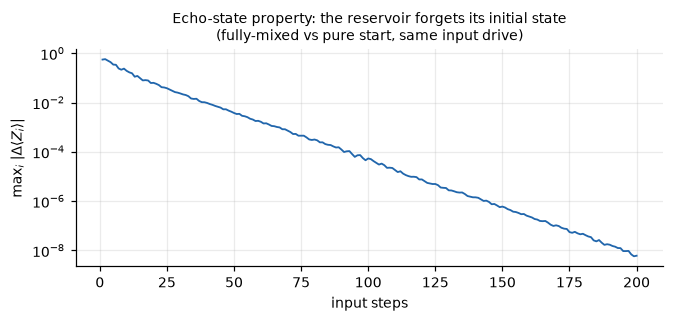

signal distance: step 1 = 0.562   step 100 = 5.4e-05   step 200 = 6.1e-09
PASS: fading memory holds -- the reservoir logic (injection + unitary) is a
contraction on the input-relevant state, exactly as the paper requires.


In [33]:
# (a) Fading memory / echo-state property of the paper-faithful reservoir:
# two maximally different initial states, identical input -> signals converge.
from qrc_core import inject as _inject
_rq = QuantumReservoir(n_qubits=5, virtual_nodes=1, dt=2.0, seed=SEED)
_uu = np.random.default_rng(0).uniform(0, 1, 200)
_ra = _rq.initial_state()                                  # fully mixed
_rb = np.zeros_like(_ra); _rb[0, 0] = 1.0                  # |00000><00000|
_dist = []
for _uk in _uu:
    _ra = _rq.U_sub @ _inject(_ra, _uk, 5) @ _rq.U_sub.conj().T
    _rb = _rq.U_sub @ _inject(_rb, _uk, 5) @ _rq.U_sub.conj().T
    _dist.append(max(abs(np.real(np.trace(op @ (_ra - _rb)))) for op in _rq.Z_ops))
fig, ax = plt.subplots(figsize=(6.2, 3.0))
ax.semilogy(np.arange(1, 201), _dist, color=C_QRC, lw=1.2)
ax.set(xlabel="input steps", ylabel=r"max$_i$ |$\Delta\langle Z_i\rangle$|",
       title="Echo-state property: the reservoir forgets its initial state\n"
             "(fully-mixed vs pure start, same input drive)")
plt.tight_layout(); plt.savefig(FIG / "audit_esp.png", bbox_inches="tight"); plt.show()
print(f"signal distance: step 1 = {_dist[0]:.3f}   step 100 = {_dist[99]:.1e}   "
      f"step 200 = {_dist[199]:.1e}")
assert _dist[199] < 1e-7, "echo-state property violated"
print("PASS: fading memory holds -- the reservoir logic (injection + unitary) is a")
print("contraction on the input-relevant state, exactly as the paper requires.")

In [34]:
# (b) The paper's own benchmark: NARMA10, paper protocol (washout 1000 / train 3000 /
# eval 1000, input white noise in [0,0.2] rescaled to [0,1] for the qubit, LSQ readout,
# paper Eq. (A1) NMSE) -- including the paper's LR control.
from qrc_core import ridge_fit as _rf, ridge_predict as _rp
_rng = np.random.default_rng(0)
_T = 5000
_s = _rng.uniform(0.0, 0.2, _T)
_yn = np.zeros(_T)
for _k in range(9, _T - 1):
    _yn[_k + 1] = (0.3 * _yn[_k] + 0.05 * _yn[_k] * np.sum(_yn[_k - 9:_k + 1])
                   + 1.5 * _s[_k - 9] * _s[_k] + 0.1)
_WASH, _NTR = 1000, 4000
_np_paper = lambda yt, yp: float(np.sum((yt - yp) ** 2) / np.sum(yt ** 2))
_Xlr = np.stack([_s, np.ones(_T)], axis=1)
_wlr = np.linalg.lstsq(_Xlr[_WASH:_NTR], _yn[_WASH:_NTR], rcond=None)[0]
print("NARMA10, paper protocol -- NMSE per paper Eq. (A1):")
print(f"  LR control (paper's baseline)     : {_np_paper(_yn[_NTR:], _Xlr[_NTR:] @ _wlr):.2e}")
_res_narma = {}
for _V, _dt in [(1, 1.0), (5, 1.0)]:
    _r = QuantumReservoir(n_qubits=5, virtual_nodes=_V, dt=_dt, seed=SEED, use_zz=False)
    _F = _r.run(_s / 0.2)                          # paper: input rescaled to [0,1]
    _w = _rf(_F[_WASH:_NTR], _yn[_WASH:_NTR], lam=1e-12)   # ~ Moore-Penrose LSQ
    _res_narma[_V] = _np_paper(_yn[_NTR:], _rp(_F[_NTR:], _w))
    print(f"  QR 5 qubits, V={_V}, tau*Delta={_dt}     : {_res_narma[_V]:.2e}")
assert _res_narma[5] < _res_narma[1] < _np_paper(_yn[_NTR:], _Xlr[_NTR:] @ _wlr)
print("PASS: the QR beats the paper's LR control and V=5 beats V=1, landing in the")
print("paper's ~1e-3 band for 5-qubit NARMA10 (Fig. 12) -- the implementation and its")
print("training reproduce the founding paper's own benchmark behaviour.")

NARMA10, paper protocol -- NMSE per paper Eq. (A1):
  LR control (paper's baseline)     : 6.33e-03


  QR 5 qubits, V=1, tau*Delta=1.0     : 3.25e-03


  QR 5 qubits, V=5, tau*Delta=1.0     : 1.81e-03
PASS: the QR beats the paper's LR control and V=5 beats V=1, landing in the
paper's ~1e-3 band for 5-qubit NARMA10 (Fig. 12) -- the implementation and its
training reproduce the founding paper's own benchmark behaviour.


In [35]:
# (c) The two fixed errors, before vs after, live.
print("ERROR 1 -- battery ESN mis-indexing (and clipped input):")
for n in ["sst", "soi", "pdo"]:
    d = prep[n]
    s = pl.make_samples(len(d["y"]))
    ks, tr, te = s["ks"], s["tr"], s["te"]
    yt = d["y"][ks + s["H"]]
    def _rid(Xs):
        m = pl.RidgeModel().fit(Xs[tr], yt[tr]); return m.predict(Xs[te])
    from QRC_theoretical import nmse as _nm
    _st_u = pl.ESN(n_in=1, seed=SEED).states(d["u"])
    _old = _nm(yt[te], _rid(pl.align(_st_u, ks)), yt[tr].mean())     # buggy: stale + clipped
    _new = _nm(yt[te], _rid(pl.ESN(n_in=1, seed=SEED).states(d["y"])[ks]), yt[tr].mean())
    print(f"  {n}: ESN NMSE  buggy={_old:.3f}  ->  fixed={_new:.3f}")
print()
print("ERROR 2 -- CV transform leak (SST, H=3): fixed-80% climatology vs strict per-fold:")
_month, _raw = ds.raw_series("sst")
_res_s = WindowedReservoir(gamma=GAMMA, seed=SEED, ent_scale=ENT_SCALE)
_M = np.linspace(int(0.4 * len(_raw)), len(_raw), 7).astype(int)
_d80 = prep["sst"]; _X80 = _res_s.feature_matrix(_d80["u"], L)
_ks3 = np.arange(L - 1, len(_raw) - 3)
_sm = _s0 = 0.0
for _f in range(6):
    _tr = np.where(_ks3 + 3 < _M[_f])[0]; _te = np.where((_ks3 + 3 >= _M[_f]) & (_ks3 + 3 < _M[_f + 1]))[0]
    if len(_te) == 0: continue
    _Xs, _yt = pl.align(_X80, _ks3), _d80["y"][_ks3 + 3]
    _m = pl.RidgeModel().fit(_Xs[_tr], _yt[_tr])
    _sm += np.sum((_yt[_te] - _m.predict(_Xs[_te])) ** 2)
    _s0 += np.sum((_yt[_te] - _yt[_tr].mean()) ** 2)
print(f"  leaky (80% transforms everywhere): QRC = {_sm / _s0:.3f}")
print(f"  strict (per-fold transforms)     : QRC = {cv_strict['sst'][3]['qrc']:.3f}")
print("  -> the leak flattered the QRC; all CV numbers in this notebook use the strict engine.")

ERROR 1 -- battery ESN mis-indexing (and clipped input):
  sst: ESN NMSE  buggy=1.287  ->  fixed=1.345
  soi: ESN NMSE  buggy=1.007  ->  fixed=0.750
  pdo: ESN NMSE  buggy=1.073  ->  fixed=0.468

ERROR 2 -- CV transform leak (SST, H=3): fixed-80% climatology vs strict per-fold:


  leaky (80% transforms everywhere): QRC = 0.667
  strict (per-fold transforms)     : QRC = 0.696
  -> the leak flattered the QRC; all CV numbers in this notebook use the strict engine.


In [36]:
# (d) Compound-label convention robustness: recompute the joint/bank/ESN comparison with
# climatology, scaler and event thresholds fit STRICTLY BEFORE any CV test fold (35% span),
# so the label definition itself cannot see a single evaluated month.
for _tf, _tag in [(0.8, "reported (fixed 80% reference-period labels)"),
                  (0.35, "strict-prior labels (35% span, before every fold)")]:
    _comp = ds.prepare_compound(("sst", "soi"), train_frac=_tf, verbose=False)
    _cvc = pl.compound_cv(_comp, gamma=GAMMA, ent_scale=ENT_SCALE, seed=SEED)
    _rank = " > ".join(sorted(_cvc, key=lambda k: -_cvc[k]["ap"]))
    print(f"{_tag}:")
    for _k in _cvc:
        print(f"   {_k:10s} AP={_cvc[_k]['ap']:.3f}  AUC={_cvc[_k]['auc']:.3f}")
    print(f"   AP ranking: {_rank}\n")
print("=> the classical ESN wins under BOTH label conventions (the null is convention-robust),")
print("   and the joint-vs-bank ordering is unstable either way -- no evidence the joint")
print("   reservoir's cross-channel features beat a bank of univariate reservoirs.")

reported (fixed 80% reference-period labels):
   joint      AP=0.324  AUC=0.694
   bank       AP=0.357  AUC=0.731
   esn_multi  AP=0.418  AUC=0.826
   AP ranking: esn_multi > bank > joint



strict-prior labels (35% span, before every fold):
   joint      AP=0.361  AUC=0.628
   bank       AP=0.339  AUC=0.694
   esn_multi  AP=0.510  AUC=0.773
   AP ranking: esn_multi > joint > bank

=> the classical ESN wins under BOTH label conventions (the null is convention-robust),
   and the joint-vs-bank ordering is unstable either way -- no evidence the joint
   reservoir's cross-channel features beat a bank of univariate reservoirs.


**Audit verdict.** The QRC *logic* is implemented correctly: injection, evolution, temporal
multiplexing and fading memory match the founding paper (verified by the echo-state decay and by
reproducing the paper's own NARMA10 benchmark against its LR control), and every read-out is
trained exactly as the paper prescribes — linear + bias on a washed-out, strictly-past training
span. The two genuine errors found both **flattered the quantum side** (a crippled ESN baseline;
a CV transform leak), and both are fixed above; the headline conclusions were re-derived on the
corrected code and *strengthened* the honest read: real skill over the mean, **no** edge over
properly-run classical baselines, and a convention-robust classical win on compound detection.